# Price Match Gurantee Use case

In [43]:
import shutil  # standard library module for high-level file operations (move, copy, etc.)
from pathlib import Path  # object-oriented filesystem path handling

attachments_dir = Path("data/attachments")  # root folder that currently holds all attachment files mixed together
ext_to_folder = {"doc": "doc", "pdf": "pdf", "jpg": "jpg"}  # maps each file extension we care about to its destination subfolder name

for folder in ext_to_folder.values():  # loop over the three destination folder names ("doc", "pdf", "jpg")
    (attachments_dir / folder).mkdir(exist_ok=True)  # create data/attachments/<folder> if it doesn't already exist; do nothing if it does

moved_counts = {ext: 0 for ext in ext_to_folder}  # running tally of how many files get moved per extension, initialized to 0

for file in attachments_dir.iterdir():  # iterate over every entry directly inside data/attachments (files and folders)
    if file.is_file():  # skip subfolders (like the doc/pdf/jpg folders just created) and only process actual files
        ext = file.suffix.lower().lstrip(".")  # get the file extension in lowercase without the leading dot, e.g. ".PDF" -> "pdf"
        if ext in ext_to_folder:  # only act on files whose extension is one we're segregating (doc, pdf, jpg); ignore others like .png
            dest = attachments_dir / ext_to_folder[ext] / file.name  # build the destination path: data/attachments/<ext>/<original filename>
            shutil.move(str(file), str(dest))  # move the file from its current location into the matching extension subfolder
            moved_counts[ext] += 1  # increment the counter for this extension to track progress

print("Files segregated:", moved_counts)  # print a summary showing how many files were moved into each folder


Files segregated: {'doc': 0, 'pdf': 0, 'jpg': 0}


## EDA

In [44]:
import pandas as pd  # import the pandas library for data manipulation and analysis

pd.set_option('display.max_columns', None)  # configure pandas to display all columns when printing DataFrames

df = pd.read_csv("data\\brg_claims.csv")  # read the CSV file into a pandas DataFrame
df.head()  # display a concise summary of the DataFrame, including the number of non-null entries and data types for each column

,CaseID,ClaimSubmissionDate,ClaimSubmissionChannel,ClaimStatus,ClaimDecisionDate,AssignedAdvisorID,AdvisorTenureMonths,IsApproved,ApprovalOrRejectionReason,CustomerComments,InternalAdvisorNotes,ClaimAmount,ClaimPoints,ApprovedAmount,ApprovedPoints,RefundAmount,RefundPoints,RefundMethod,BetterRateURL,BetterRateVendorName,BetterRateAmount,MinimumClaimThresholdMet,Attachment1,Attachment2,Attachment3,Attachment4,Attachment5,AttachmentCount,ProofType,ProofQualityFlag,RestrictionsMatchFlag,SLATargetHours,TimeToAdjudicateMinutes,SLAHoursElapsed,SLABreached,AdjudicationLaborCost,CustomerID,FirstName,LastName,Phone,Email,AddressStreet,AddressCity,AddressState,AddressZip,AddressCountry,LoyaltyTier,LoyaltyMemberSinceDate,CustomerLifetimeValue,PriorClaimsCount,PriorApprovedClaimsCount,PriorApprovalRate,AccountStatus,BookingID,IsMultiSegmentBooking,BookingType,BookingChannel,BookingAmount,BookingCurrency,BookingDate,TravelStartDate,TravelEndDate,TripDurationDays,FareOrRatePlanFlexibility,BookingSpecialConsiderations,ClaimSubmittedRelativeToTravel,BlackoutDateOrExcludedFare,Airline,FareClass,Origin,Destination,NumberOfStops,FareType,PropertyName,RoomType,StarRating,MealPlan,CheckInDate,CheckOutDate,NumberOfRooms,RentalCompany,VehicleClass,PickupLocation,DropoffLocation,RentalDurationDays,CruiseLine,ShipName,CabinType,PortsOfCall,NightsDuration,SegmentList,NumberOfPassengers,PassengerDetails,IsFamilyBooking,DaysBookingToClaim,DaysClaimToTravelStart,RateDifferenceAmount,RateDifferencePercent,AttachmentCompletenessScore,HasValidBetterRateURL,AdvisorCaseloadAtSubmission,SeasonalityFlag,LoyaltyTierOrdinal,LegitimacyScore
0,PTS-CLM-000746,8/9/2024 2:11,Mobile App,Closed,8/9/2024 9:45,PTS-ADV-0023,118,No,Insufficient or unverifiable documentation,Found a lower rate on Travelocity for the same...,Reviewed by PTS-ADV-0023: insufficient or unve...,304.08,0,0.00,0,0.00,0,NaN,https://www.travelocity.com/listing/746,Travelocity,138.88,True,NaN,NaN,NaN,NaN,NaN,0,NaN,Insufficient,True,24,47,7.57,False,39.17,PTS-CUST-000323,Dan,Cox,503-428-1139,avilakyle@hotmail.com,034 Tiffany Port,New Valeriefort,AZ,6798,USA,Gold,6/12/2018,3843.44,0,0,0.5,Active,PTS-BKG-000746,False,Car,PTS Web,440.82,USD,4/14/2024,8/30/2024,9/1/2024,2,Refundable,Companion fare,Before Travel,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Enterprise,SUV,Mariaton,Russellburgh,13.0,NaN,NaN,NaN,NaN,NaN,NaN,1,"[{""PassengerID"": ""PAX-1"", ""Name"": ""Russell Hol...",False,117,21,301.94,0.6850,0.00,True,1,Peak,2,42.0
1,PTS-CLM-000012,8/9/2024 18:42,Mobile App,Rejected,8/10/2024 1:22,PTS-ADV-0120,81,No,Competing rate not from an eligible/comparable...,NaN,Reviewed by PTS-ADV-0120: competing rate not f...,79.17,0,0.00,0,0.00,0,NaN,NaN,Priceline,125.65,True,PTS-CLM-000012-att1.doc,PTS-CLM-000012-att2.png,NaN,NaN,NaN,2,Screenshot,Ambiguous,True,24,37,6.67,False,30.83,PTS-CUST-000006,Natalie,Arroyo,171-822-7824,ibrandt@hotmail.com,465 Lam Mission,East Jeffreymouth,AK,77611,USA,Silver,9/12/2020,414.90,0,0,0.5,Active,PTS-BKG-000012,False,Cruise,PTS Web,201.41,USD,5/29/2024,8/7/2024,8/12/2024,5,Partially Flexible,NaN,During Travel,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Norwegian,MS Jose,Balcony,"[""Barcelona"", ""St. Thomas"", ""Rome"", ""Nassau""]",5.0,NaN,4,"[{""PassengerID"": ""PAX-1"", ""Name"": ""Jeffrey Har...",True,72,-2,75.76,0.3761,0.44,False,1,Peak,1,61.0
2,PTS-CLM-000542,8/12/2024 2:02,Web,Approved,8/12/2024 9:46,PTS-ADV-0064,19,Yes,Within all program eligibility guidelines,Found a lower rate on Orbitz for the same car ...,Reviewed by PTS-ADV-0064: within all program e...,132.50,0,122.82,0,122.82,0,Split,https://www.orbitz.com/listing/542,Orbitz,336.32,True,PTS-CLM-000542-att1.doc,NaN,NaN,NaN,NaN,1,NaN,Insufficient,True,24,41,7.73,False,34.17,PTS-CUST-000201,Amy,Morris,309-251-1426,heathertran@yahoo.com,021 Strickland Brook,Millertown,HI,12184,USA,Platinum,5/26/2026,1814.96,0,0,0.5,VIP-Flagged,PTS-BKG-000542,False,Car,App,460.73,USD,5/11/20

### Claim Status Distribution

In [45]:
status_counts = df['ClaimStatus'].value_counts()
total_claims = status_counts.sum()

status_summary = status_counts.rename('Count').to_frame()
status_summary['Percent'] = (status_summary['Count'] / total_claims * 100).round(1)
status_summary

,Count,Percent
ClaimStatus,,
Approved,529,52.9
Rejected,316,31.6
Closed,78,7.8
Escalated,77,7.7


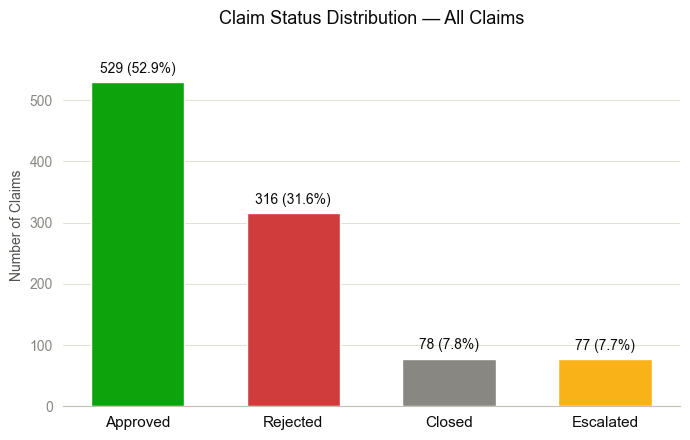

In [46]:
import matplotlib.pyplot as plt

# Semantic status colors: Approved=good, Rejected=critical, Escalated=warning, Closed=neutral
status_colors = {
    'Approved': '#0ca30c',
    'Rejected': '#d03b3b',
    'Escalated': '#fab219',
    'Closed': '#898781',
}

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    status_counts.index,
    status_counts.values,
    color=[status_colors.get(s, '#52514e') for s in status_counts.index],
    width=0.6,
    zorder=3,
)

for bar, count in zip(bars, status_counts.values):
    pct = count / total_claims * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_claims * 0.01,
             f"{count} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10, color='#0b0b0b')

ax.set_title('Claim Status Distribution — All Claims', fontsize=13, color='#0b0b0b', pad=14)
ax.set_ylabel('Number of Claims', color='#52514e')
ax.set_xlabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=11)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

### Claim Status Distribution by Country

Unique countries in AddressCountry: 1


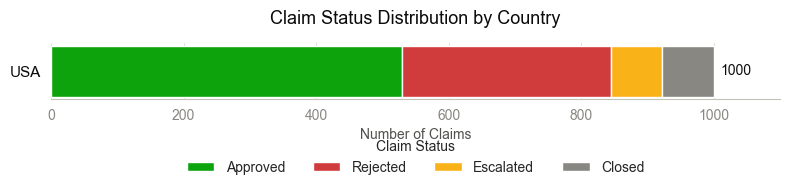

In [47]:
print("Unique countries in AddressCountry:", df['AddressCountry'].nunique())

country_status = pd.crosstab(df['AddressCountry'], df['ClaimStatus'])
country_status = country_status[[c for c in status_colors if c in country_status.columns]]

fig, ax = plt.subplots(figsize=(8, 2.2 + 0.6 * len(country_status)))
left = pd.Series(0, index=country_status.index)
for status in country_status.columns:
    ax.barh(country_status.index, country_status[status], left=left,
            color=status_colors.get(status, '#52514e'), label=status, height=0.5, zorder=3)
    left = left + country_status[status]

for i, country in enumerate(country_status.index):
    row_total = country_status.loc[country].sum()
    ax.text(row_total + row_total * 0.01, i, f"{row_total}", va='center', ha='left',
             fontsize=10, color='#0b0b0b')

ax.set_title('Claim Status Distribution by Country', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('Number of Claims', color='#52514e')
ax.set_ylabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=11)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.margins(x=0.1)
ax.legend(title='Claim Status', loc='upper center', bbox_to_anchor=(0.5, -0.5),
          ncol=4, frameon=False)
plt.tight_layout()
plt.show()

### Claim Status Distribution by City (Top 15 by Volume)

`AddressCity` has 470 unique values, most with only 1–6 claims, so plotting every city is unreadable. Showing the top 15 cities by total claim count instead.

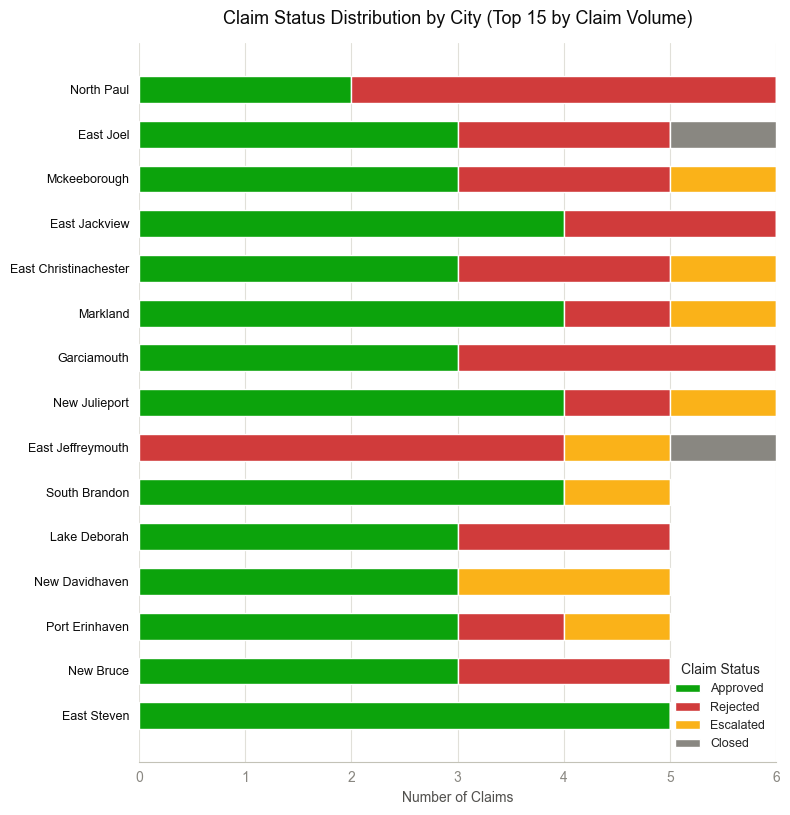

In [48]:
top_n = 15
top_cities = df['AddressCity'].value_counts().head(top_n).index

city_status = pd.crosstab(df['AddressCity'], df['ClaimStatus']).loc[top_cities]
city_status = city_status[[c for c in status_colors if c in city_status.columns]]
city_status = city_status.loc[city_status.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(8, 0.45 * len(city_status) + 1.5))
left = pd.Series(0, index=city_status.index)
for status in city_status.columns:
    ax.barh(city_status.index, city_status[status], left=left,
            color=status_colors.get(status, '#52514e'), label=status, height=0.6, zorder=3)
    left = left + city_status[status]

ax.set_title(f'Claim Status Distribution by City (Top {top_n} by Claim Volume)',
             fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('Number of Claims', color='#52514e')
ax.set_ylabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=9)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Claim Status', loc='lower right', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### Feature Correlation with Claim Rejections — North Paul

`North Paul` has only 6 total claims (2 Approved, 4 Rejected), so any correlation computed on it alone is statistically fragile. The cells below compute it anyway, then sanity-check the result against the full 1,000-claim dataset to see whether it's a real signal or a small-sample artifact.

In [49]:
north_paul = df[df['AddressCity'] == 'North Paul'].copy()
north_paul['IsRejected'] = (north_paul['ClaimStatus'] == 'Rejected').astype(int)

print(f"North Paul claims: {len(north_paul)} total")
print(north_paul['ClaimStatus'].value_counts())

north_paul[['CaseID', 'ClaimStatus', 'ApprovalOrRejectionReason', 'ProofQualityFlag',
            'RestrictionsMatchFlag', 'AttachmentCompletenessScore']]

North Paul claims: 6 total
ClaimStatus
Rejected    4
Approved    2
Name: count, dtype: int64


,CaseID,ClaimStatus,ApprovalOrRejectionReason,ProofQualityFlag,RestrictionsMatchFlag,AttachmentCompletenessScore
495,PTS-CLM-000342,Approved,Within all program eligibility guidelines,Ambiguous,False,0.32
514,PTS-CLM-000343,Rejected,Restrictions/flexibility do not match,Verified,False,0.52
594,PTS-CLM-000344,Rejected,Blackout date / excluded fare or rate plan,Verified,True,0.88
837,PTS-CLM-000345,Rejected,Restrictions/flexibility do not match,Verified,False,0.64
901,PTS-CLM-000346,Approved,Within all program eligibility guidelines,Ambiguous,True,0.32
930,PTS-CLM-000347,Rejected,Restrictions/flexibility do not match,Verified,False,0.88


In [50]:
import numpy as np

num_cols = north_paul.select_dtypes(include=[np.number]).columns.drop('IsRejected')
# require data on at least 4 of 6 rows and non-zero variance, otherwise the
# correlation is either undefined or based on too few points to mean anything
usable_cols = [c for c in num_cols
               if north_paul[c].notna().sum() >= 4 and north_paul[c].std() > 0]

corr_with_rejection = (
    north_paul[usable_cols]
    .corrwith(north_paul['IsRejected'])
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
corr_with_rejection.head(10).to_frame('Correlation with Rejection')

,Correlation with Rejection
AttachmentCompletenessScore,0.835171
RefundAmount,-0.716694
ApprovedAmount,-0.716694
RateDifferenceAmount,0.676949
ClaimAmount,0.648673
RefundPoints,-0.632456
ApprovedPoints,-0.632456
DaysClaimToTravelStart,-0.621837
AttachmentCount,0.613941
PriorApprovedClaimsCount,0.612372


In [51]:
for col in ['ProofQualityFlag', 'RestrictionsMatchFlag', 'FareOrRatePlanFlexibility']:
    print(f"--- {col} ---")
    print(pd.crosstab(north_paul[col], north_paul['ClaimStatus']))
    print()

--- ProofQualityFlag ---
ClaimStatus       Approved  Rejected
ProofQualityFlag                    
Ambiguous                2         0
Verified                 0         4

--- RestrictionsMatchFlag ---
ClaimStatus            Approved  Rejected
RestrictionsMatchFlag                    
False                         1         3
True                          1         1

--- FareOrRatePlanFlexibility ---
ClaimStatus                Approved  Rejected
FareOrRatePlanFlexibility                    
Non-Refundable                    1         0
Partially Flexible                1         1
Refundable                        0         3



In [52]:
# Sanity check: does the North Paul pattern hold across the full 1,000-claim dataset?
print("ProofQualityFlag vs ClaimStatus, full dataset (row %):")
print(pd.crosstab(df['ProofQualityFlag'], df['ClaimStatus'], normalize='index').round(3))
print()

print("Mean AttachmentCompletenessScore by ClaimStatus, full dataset:")
print(df.groupby('ClaimStatus')['AttachmentCompletenessScore'].mean().round(3))

ProofQualityFlag vs ClaimStatus, full dataset (row %):
ClaimStatus       Approved  Closed  Escalated  Rejected
ProofQualityFlag                                       
Ambiguous            0.465   0.077      0.065     0.392
Insufficient         0.411   0.100      0.078     0.411
Verified             0.615   0.069      0.083     0.234

Mean AttachmentCompletenessScore by ClaimStatus, full dataset:
ClaimStatus
Approved     0.541
Closed       0.478
Escalated    0.495
Rejected     0.434
Name: AttachmentCompletenessScore, dtype: float64


**Conclusion:** Within North Paul's 6 claims, `ProofQualityFlag` and `AttachmentCompletenessScore` appear to perfectly separate Approved from Rejected. But the full-dataset sanity check shows the *opposite* relationship — "Verified" proof quality and higher attachment completeness are both associated with **more** approvals dataset-wide, not more rejections. That confirms the North Paul correlation is a small-sample artifact, not a real driver.

The actual explanation for North Paul's rejections is in `ApprovalOrRejectionReason`: 3 of 4 are "Restrictions/flexibility do not match" and 1 is a blackout-date/excluded-fare issue — an operational pattern, not a statistical one.

## 1. Month-wise Claim Status

The data spans multiple years (2024-2026), so grouping by calendar month name — pooling all years together — surfaces the underlying seasonal pattern (e.g. summer travel spikes) instead of splitting it across separate Year-Month buckets. `ClaimSubmissionDate` is parsed and mapped to its month name, ordered January through December.

In [53]:
# Parse the submission timestamp and derive the calendar month name (year-agnostic)
df['ClaimSubmissionDate'] = pd.to_datetime(df['ClaimSubmissionDate'])
df['SubmissionMonthName'] = df['ClaimSubmissionDate'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Counts of each claim status per calendar month, pooled across all years in the data
month_status = pd.crosstab(df['SubmissionMonthName'], df['ClaimStatus']).reindex(month_order).fillna(0).astype(int)
month_status = month_status[[c for c in status_colors if c in month_status.columns]]
month_status

ClaimStatus,Approved,Rejected,Escalated,Closed
SubmissionMonthName,,,,
January,43,22,7,3
February,35,27,7,7
March,46,23,9,12
April,49,33,3,5
May,42,24,6,1
June,39,26,9,13
July,38,24,5,5
August,34,33,5,8
September,52,28,9,9


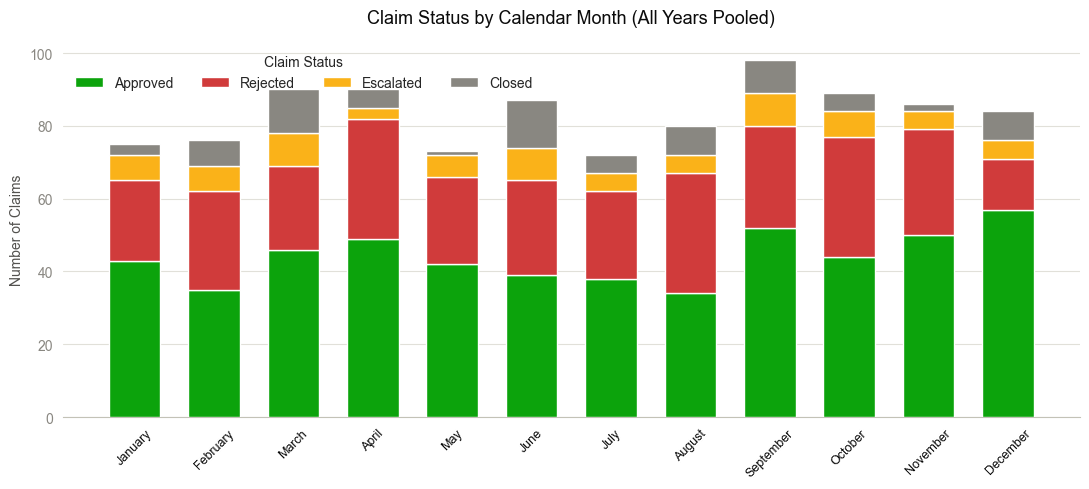

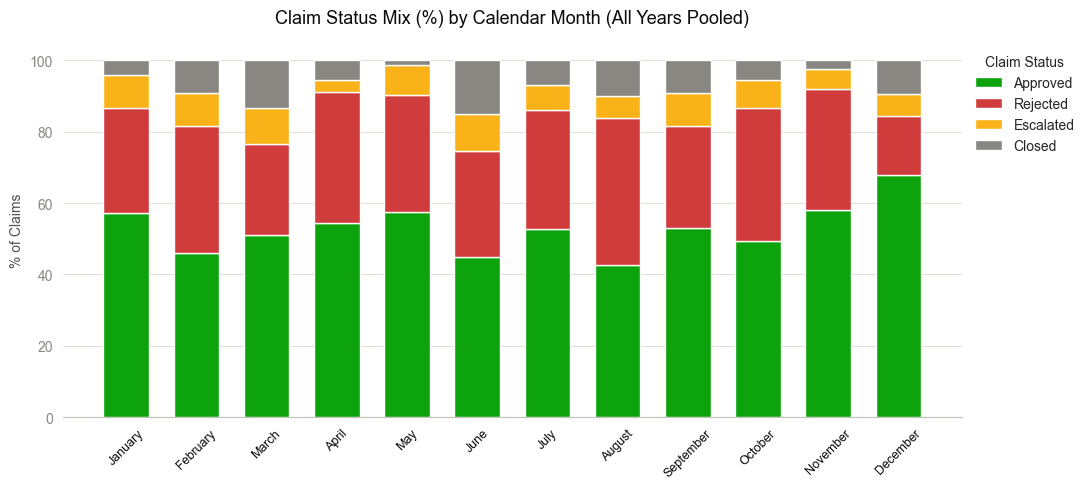

In [54]:
# Stacked bar chart: claim volume by calendar month (all years pooled), colored by status
fig, ax = plt.subplots(figsize=(11, 5))
bottom = pd.Series(0, index=month_status.index)
for status in month_status.columns:
    ax.bar(month_status.index, month_status[status], bottom=bottom,
           color=status_colors.get(status, '#52514e'), label=status, width=0.65, zorder=3)
    bottom = bottom + month_status[status]

ax.set_title('Claim Status by Calendar Month (All Years Pooled)', fontsize=13, color='#0b0b0b', pad=14)
ax.set_ylabel('Number of Claims', color='#52514e')
ax.set_xlabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=9, rotation=45)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Claim Status', loc='upper left', frameon=False, ncol=4)
plt.tight_layout()
plt.show()

# Same data as a % mix per month, to separate "how many claims" from "how the outcome mix changed"
month_status_pct = month_status.div(month_status.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 5))
bottom = pd.Series(0.0, index=month_status_pct.index)
for status in month_status_pct.columns:
    ax.bar(month_status_pct.index, month_status_pct[status], bottom=bottom,
           color=status_colors.get(status, '#52514e'), label=status, width=0.65, zorder=3)
    bottom = bottom + month_status_pct[status]

ax.set_title('Claim Status Mix (%) by Calendar Month (All Years Pooled)', fontsize=13, color='#0b0b0b', pad=14)
ax.set_ylabel('% of Claims', color='#52514e')
ax.set_xlabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=9, rotation=45)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Claim Status', loc='upper left', bbox_to_anchor=(1.0, 1.0), frameon=False)
plt.tight_layout()
plt.show()

## 2. Claim Submission Channel vs. Claim Status

Cross-tabulate `ClaimSubmissionChannel` against `ClaimStatus` and run a chi-square test of independence to check whether the channel a customer submits through is statistically associated with the outcome.

In [55]:
channel_status = pd.crosstab(df['ClaimSubmissionChannel'], df['ClaimStatus'])
channel_status = channel_status[[c for c in status_colors if c in channel_status.columns]]

# Row-normalized (%) view is what actually answers "does channel change the outcome mix"
channel_status_pct = (channel_status.div(channel_status.sum(axis=1), axis=0) * 100).round(1)
display(channel_status)
display(channel_status_pct)

ClaimStatus,Approved,Rejected,Escalated,Closed
ClaimSubmissionChannel,,,,
Call Center,94,61,11,13
Email,59,33,10,7
Mobile App,131,78,20,20
Travel Agent,41,20,3,9
Web,204,124,33,29


ClaimStatus,Approved,Rejected,Escalated,Closed
ClaimSubmissionChannel,,,,
Call Center,52.5,34.1,6.1,7.3
Email,54.1,30.3,9.2,6.4
Mobile App,52.6,31.3,8.0,8.0
Travel Agent,56.2,27.4,4.1,12.3
Web,52.3,31.8,8.5,7.4


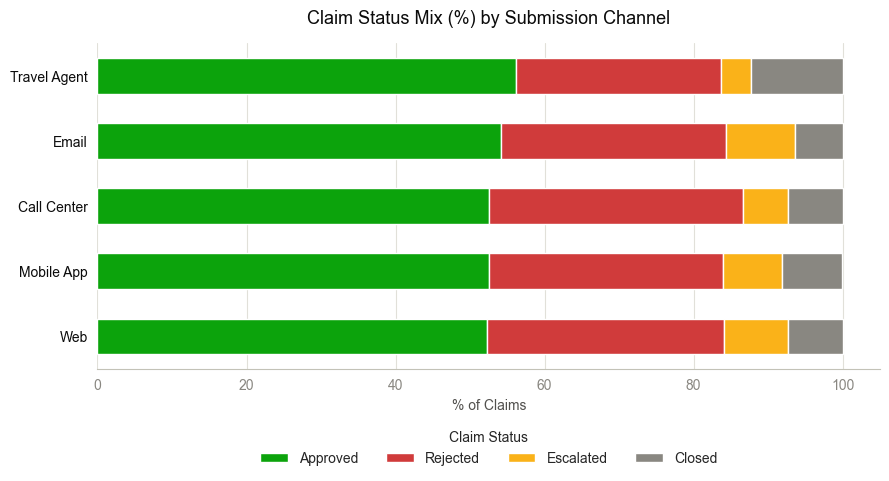

In [56]:
# 100% stacked bar of claim status mix per submission channel, ordered by claim volume
channel_order = channel_status.sum(axis=1).sort_values(ascending=False).index
plot_pct = channel_status_pct.loc[channel_order]

fig, ax = plt.subplots(figsize=(9, 5))
left = pd.Series(0.0, index=plot_pct.index)
for status in plot_pct.columns:
    ax.barh(plot_pct.index, plot_pct[status], left=left,
            color=status_colors.get(status, '#52514e'), label=status, height=0.55, zorder=3)
    left = left + plot_pct[status]

ax.set_title('Claim Status Mix (%) by Submission Channel', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('% of Claims', color='#52514e')
ax.set_ylabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=10)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Claim Status', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

In [57]:
from scipy.stats import chi2_contingency

# Chi-square test of independence: H0 = ClaimSubmissionChannel and ClaimStatus are independent
chi2, p_value, dof, expected = chi2_contingency(channel_status)

# Cramer's V: effect size for the association (0 = none, 1 = perfect), needed because
# chi-square's p-value alone doesn't say how *strong* the relationship is
n = channel_status.values.sum()
k = min(channel_status.shape) - 1
cramers_v = (chi2 / (n * k)) ** 0.5

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.4f}")
print(f"Cramer's V:           {cramers_v:.3f}")
print()
if p_value < 0.05:
    print("=> p < 0.05: statistically significant association between channel and claim status.")
else:
    print("=> p >= 0.05: no statistically significant association detected between channel and claim status.")
print("   (Cramer's V close to 0 means the association, even if significant, is practically weak.)")

Chi-square statistic: 5.80
Degrees of freedom:   12
p-value:              0.9260
Cramer's V:           0.044

=> p >= 0.05: no statistically significant association detected between channel and claim status.
   (Cramer's V close to 0 means the association, even if significant, is practically weak.)


## 3. Word Clouds: Approval vs. Rejection Reasons

`ApprovalOrRejectionReason` holds the reason text for every claim. Split it by `IsApproved` and render one word cloud for approved-claim reasons and one for rejected/not-approved-claim reasons, to see which phrases dominate each outcome at a glance.

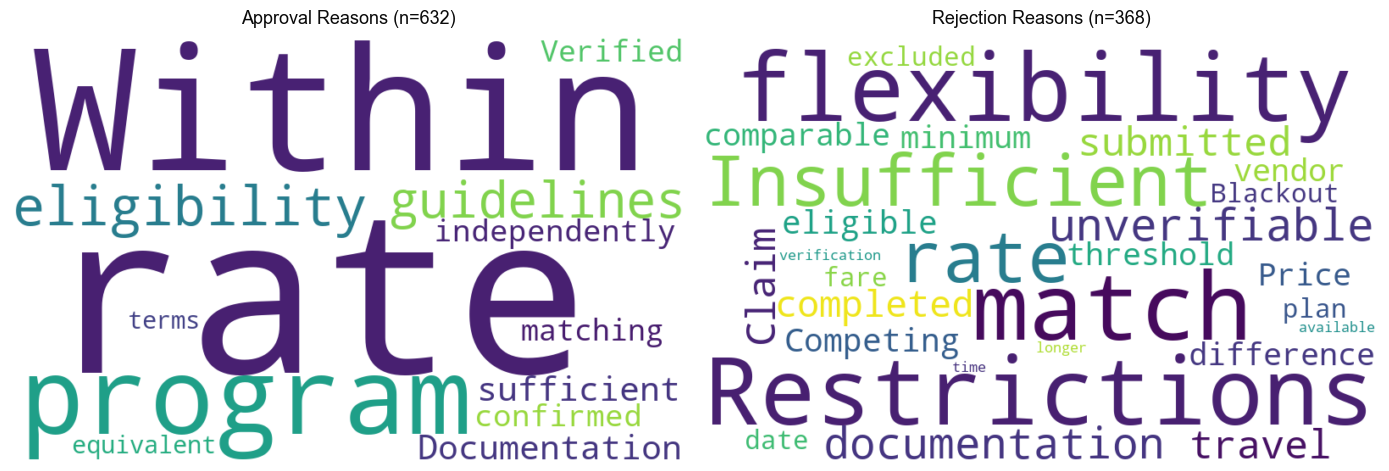

In [58]:
from wordcloud import WordCloud

def make_wordcloud(text_series, title, ax):
    """Render a word cloud for a pandas Series of text onto a given matplotlib axis."""
    text = " ".join(text_series.dropna().astype(str))
    wc = WordCloud(width=800, height=500, background_color='white',
                    colormap='viridis', collocations=False, random_state=42).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, color='#0b0b0b', pad=10)
    ax.axis('off')

approved_reasons = df.loc[df['IsApproved'] == 'Yes', 'ApprovalOrRejectionReason']
rejected_reasons = df.loc[df['IsApproved'] == 'No', 'ApprovalOrRejectionReason']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
make_wordcloud(approved_reasons, f'Approval Reasons (n={approved_reasons.notna().sum()})', axes[0])
make_wordcloud(rejected_reasons, f'Rejection Reasons (n={rejected_reasons.notna().sum()})', axes[1])
plt.tight_layout()
plt.show()

## 4. Word Clouds: Customer Comments vs. Internal Advisor Notes

Reuses the `make_wordcloud` helper from the previous section to visualize the most frequent terms customers use in `CustomerComments` versus the language advisors use internally in `InternalAdvisorNotes`.

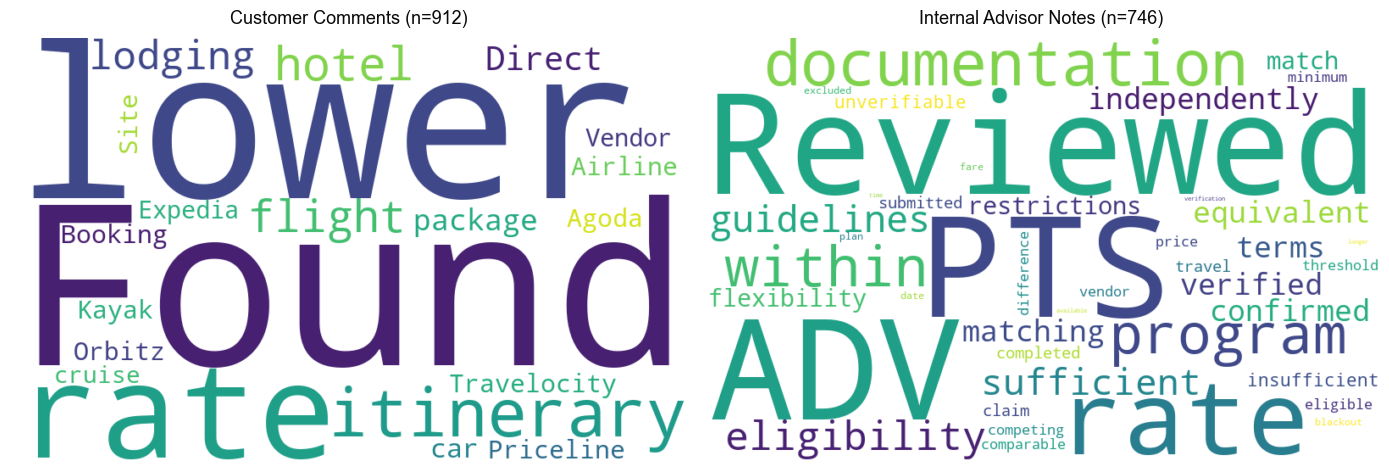

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
make_wordcloud(df['CustomerComments'],
                f"Customer Comments (n={df['CustomerComments'].notna().sum()})", axes[0])
make_wordcloud(df['InternalAdvisorNotes'],
                f"Internal Advisor Notes (n={df['InternalAdvisorNotes'].notna().sum()})", axes[1])
plt.tight_layout()
plt.show()

## 5. Distribution of Claim Amount by Channel and City

Boxplots of `ClaimAmount` split by `ClaimSubmissionChannel`, and by the top 10 `AddressCity` values by claim volume (long tail of one-off cities excluded for readability, as in the earlier city section).

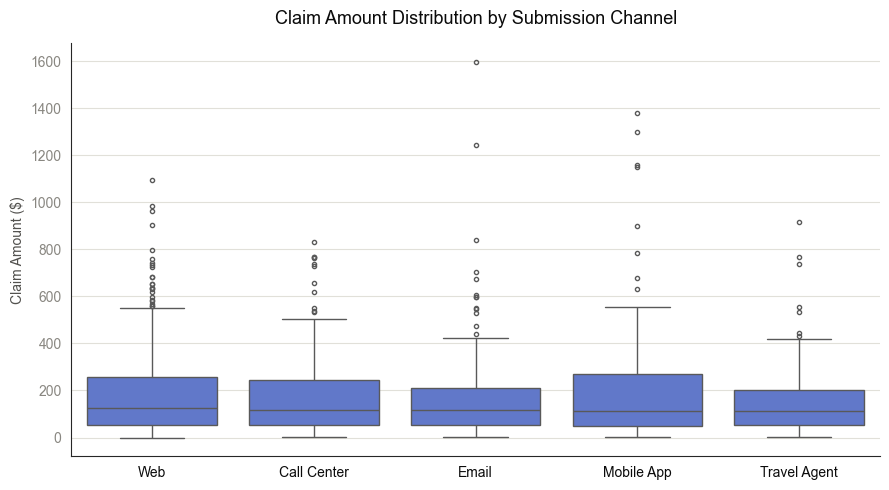

In [60]:
import seaborn as sns

sns.set_style("white")

fig, ax = plt.subplots(figsize=(9, 5))
channel_order_amt = df.groupby('ClaimSubmissionChannel')['ClaimAmount'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='ClaimSubmissionChannel', y='ClaimAmount', order=channel_order_amt,
            color='#4f6fdb', ax=ax, fliersize=3)

ax.set_title('Claim Amount Distribution by Submission Channel', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('')
ax.set_ylabel('Claim Amount ($)', color='#52514e')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=10)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

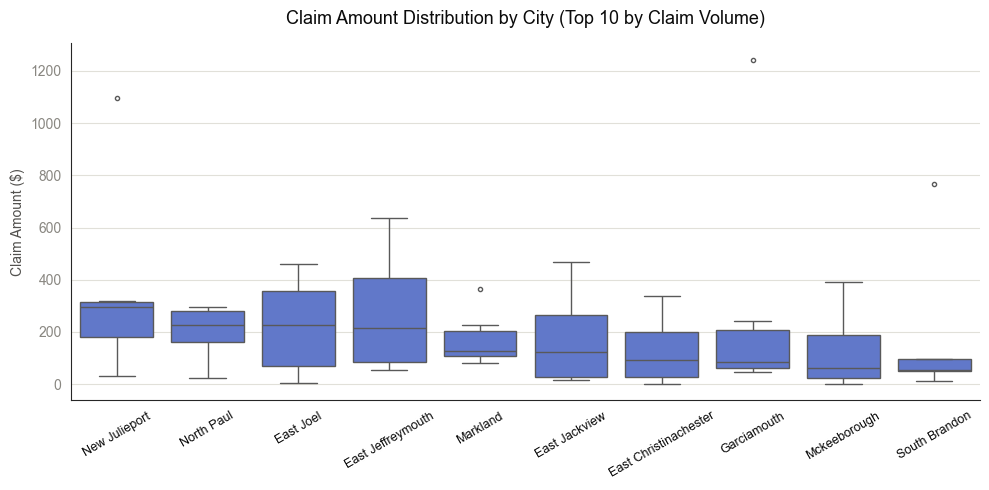

In [61]:
# Reuse the top-15-city list computed earlier; take the top 10 of those by volume for a cleaner boxplot
top_cities_amt = df['AddressCity'].value_counts().head(10).index
city_amt_df = df[df['AddressCity'].isin(top_cities_amt)]
city_order_amt = city_amt_df.groupby('AddressCity')['ClaimAmount'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=city_amt_df, x='AddressCity', y='ClaimAmount', order=city_order_amt,
            color='#4f6fdb', ax=ax, fliersize=3)

ax.set_title('Claim Amount Distribution by City (Top 10 by Claim Volume)', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('')
ax.set_ylabel('Claim Amount ($)', color='#52514e')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=9, rotation=30)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 6. Distribution of the Rate Difference Between the Competing Vendor and Us

`RateDifferenceAmount` and `RateDifferencePercent` capture how much cheaper the competing (`BetterRateAmount`) rate is versus our price. Plot both distributions to understand the typical size of the gap customers are claiming.

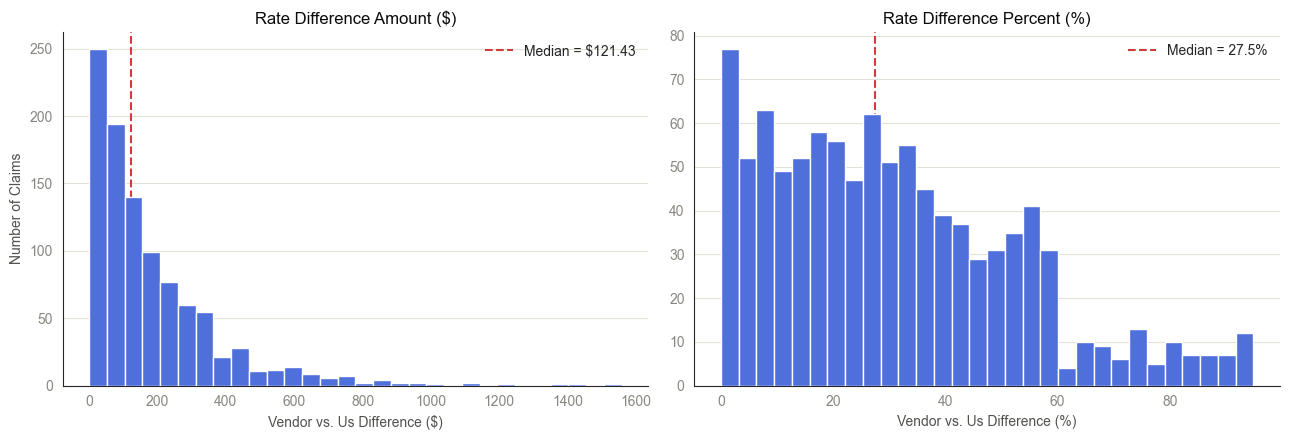

,RateDifferenceAmount,RateDifferencePercent
count,1000.000000,1000.000000
mean,183.554420,0.310307
std,194.448554,0.221755
min,0.010000,0.000000
25%,52.070000,0.130825
50%,121.430000,0.274600
75%,251.755000,0.452175
max,1557.830000,0.949100


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['RateDifferenceAmount'], bins=30, color='#4f6fdb', edgecolor='white', zorder=3)
axes[0].axvline(df['RateDifferenceAmount'].median(), color='#d03b3b', linestyle='--', linewidth=1.5,
                 label=f"Median = ${df['RateDifferenceAmount'].median():.2f}")
axes[0].set_title('Rate Difference Amount ($)', fontsize=12, color='#0b0b0b')
axes[0].set_xlabel('Vendor vs. Us Difference ($)', color='#52514e')
axes[0].set_ylabel('Number of Claims', color='#52514e')
axes[0].legend(frameon=False)

axes[1].hist(df['RateDifferencePercent'] * 100, bins=30, color='#4f6fdb', edgecolor='white', zorder=3)
axes[1].axvline(df['RateDifferencePercent'].median() * 100, color='#d03b3b', linestyle='--', linewidth=1.5,
                 label=f"Median = {df['RateDifferencePercent'].median()*100:.1f}%")
axes[1].set_title('Rate Difference Percent (%)', fontsize=12, color='#0b0b0b')
axes[1].set_xlabel('Vendor vs. Us Difference (%)', color='#52514e')
axes[1].set_ylabel('')
axes[1].legend(frameon=False)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(colors='#898781')
    ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

df[['RateDifferenceAmount', 'RateDifferencePercent']].describe()

### Deep-Dive: Claims With a Rate Difference Greater Than 85%

**Which column to use:** `RateDifferencePercent`. It is stored as a decimal fraction (0.85 = 85%), and it is calculated as:

`RateDifferencePercent = (BookingAmount - BetterRateAmount) / BookingAmount`

In plain terms:
- `BookingAmount` = what the customer actually paid us for the trip/car/room/etc.
- `BetterRateAmount` = the cheaper price the customer found for the same booking somewhere else (the "competing vendor" rate).
- `RateDifferenceAmount` = the dollar gap between the two (`BookingAmount - BetterRateAmount`).
- `RateDifferencePercent` = that dollar gap expressed as a percentage of what we charged.

So a claim with `RateDifferencePercent` > 0.85 means the customer found a rate more than **85% cheaper** than what we charged them — these are the most extreme claims in the dataset and worth a closer look, since a gap that large is either a genuinely huge pricing miss or a sign the "competing rate" isn't really comparable (wrong dates, different room/cabin/fare class, etc.).

In [63]:
# Filter to claims where the customer's competing rate was more than 85% cheaper than what we charged
extreme_rate_diff_claims = df.loc[
    df['RateDifferencePercent'] > 0.85,
    ['CaseID', 'BookingAmount', 'BetterRateAmount', 'BetterRateVendorName',
     'RateDifferenceAmount', 'RateDifferencePercent', 'ClaimStatus', 'IsApproved',
     'ApprovalOrRejectionReason']
].sort_values('RateDifferencePercent', ascending=False).reset_index(drop=True)

print(f"{len(extreme_rate_diff_claims)} claims out of {len(df)} have a rate difference greater than 85% "
      f"({len(extreme_rate_diff_claims) / len(df) * 100:.1f}% of all claims).")
extreme_rate_diff_claims

28 claims out of 1000 have a rate difference greater than 85% (2.8% of all claims).


,CaseID,BookingAmount,BetterRateAmount,BetterRateVendorName,RateDifferenceAmount,RateDifferencePercent,ClaimStatus,IsApproved,ApprovalOrRejectionReason
0,PTS-CLM-000211,284.85,14.51,Kayak,270.34,0.9491,Rejected,No,Claim submitted after travel completed
1,PTS-CLM-000393,283.54,14.83,Travelocity,268.71,0.9477,Approved,Yes,Documentation sufficient and rate independentl...
2,PTS-CLM-000341,189.49,10.07,Expedia,179.42,0.9469,Approved,Yes,Documentation sufficient and rate independentl...
3,PTS-CLM-000496,929.86,53.11,Priceline,876.75,0.9429,Rejected,No,Competing rate not from an eligible/comparable...
4,PTS-CLM-000370,442.42,25.68,Direct Airline Site,416.74,0.9420,Approved,Yes,Documentation sufficient and rate independentl...
5,PTS-CLM-000354,704.63,41.64,Direct Airline Site,662.99,0.9409,Approved,Yes,Documentation sufficient and rate independentl...
6,PTS-CLM-000514,339.81,21.41,Booking.com,318.40,0.9370,Approved,Yes,Verified matching rate with equivalent terms
7,PTS-CLM-000773,313.47,21.27,Kayak,292.20,0.9321,Escalated,No,Competing rate not from an eligible/comparable...
8,PTS-CLM-000474,239.25,17.10,Hotels.com,222.15,0.9285,Approved,Yes,Within all program eligibility guidelines
9,PTS-CLM-000846,615.58,44.35,Direct Airline Site,571.23,0.9280,Rejected,No,Competing rate not from an eligible/comparable...


In [64]:
# Walk through the 5 most extreme cases in plain language
for _, row in extreme_rate_diff_claims.head(5).iterrows():
    pct = row['RateDifferencePercent'] * 100
    print(
        f"Claim {row['CaseID']}: we charged ${row['BookingAmount']:,.2f}, but the customer found the same "
        f"booking for just ${row['BetterRateAmount']:,.2f} at {row['BetterRateVendorName']} — "
        f"a ${row['RateDifferenceAmount']:,.2f} gap, or {pct:.1f}% cheaper than what we charged. "
        f"This claim was ultimately {row['ClaimStatus']} "
        f"(reason: {row['ApprovalOrRejectionReason']})."
    )
    print()

Claim PTS-CLM-000211: we charged $284.85, but the customer found the same booking for just $14.51 at Kayak — a $270.34 gap, or 94.9% cheaper than what we charged. This claim was ultimately Rejected (reason: Claim submitted after travel completed).

Claim PTS-CLM-000393: we charged $283.54, but the customer found the same booking for just $14.83 at Travelocity — a $268.71 gap, or 94.8% cheaper than what we charged. This claim was ultimately Approved (reason: Documentation sufficient and rate independently confirmed).

Claim PTS-CLM-000341: we charged $189.49, but the customer found the same booking for just $10.07 at Expedia — a $179.42 gap, or 94.7% cheaper than what we charged. This claim was ultimately Approved (reason: Documentation sufficient and rate independently confirmed).

Claim PTS-CLM-000496: we charged $929.86, but the customer found the same booking for just $53.11 at Priceline — a $876.75 gap, or 94.3% cheaper than what we charged. This claim was ultimately Rejected (reas

**How to read the outcomes:** of the 28 extreme claims, some are `Approved` (we honored the huge gap), some are `Rejected` (likely because the "cheaper" rate wasn't actually comparable — different dates, class, or an ineligible vendor per `ApprovalOrRejectionReason`), and some are still `Escalated`. The `extreme_rate_diff_claims` DataFrame above holds the full list so you can inspect each case's proof, reasoning, and outcome directly.

## 7. Which Proof Type Has the Higher Rejection Rate?

`ProofType` is missing for claims that never attached proof; those are treated as their own "No Proof Provided" category since a missing proof type is itself informative about rejection risk. Rejection rate = Rejected claims / total claims for that proof type.

In [65]:
df['ProofTypeFilled'] = df['ProofType'].fillna('No Proof Provided')

proof_status = pd.crosstab(df['ProofTypeFilled'], df['ClaimStatus'])
proof_status = proof_status[[c for c in status_colors if c in proof_status.columns]]

# Rejection rate per proof type, sorted descending
rejection_rate = (proof_status.get('Rejected', 0) / proof_status.sum(axis=1) * 100).sort_values(ascending=False)
rejection_summary = rejection_rate.rename('RejectionRatePct').to_frame()
rejection_summary['TotalClaims'] = proof_status.sum(axis=1).loc[rejection_summary.index]
rejection_summary

,RejectionRatePct,TotalClaims
ProofTypeFilled,,
No Proof Provided,40.104167,192
Screenshot,35.376045,359
Confirmation Email,27.906977,172
PDF Quote,23.104693,277


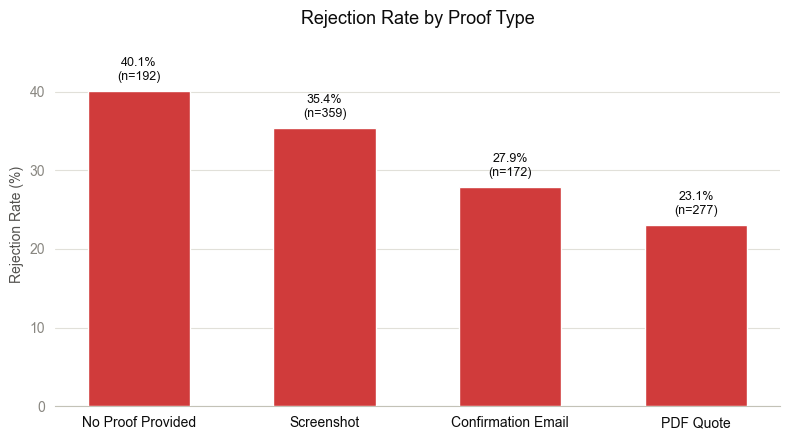

Highest rejection rate: No Proof Provided at 40.1%


In [66]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(rejection_summary.index, rejection_summary['RejectionRatePct'],
               color='#d03b3b', width=0.55, zorder=3)

for bar, (rate, total) in zip(bars, rejection_summary.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{rate:.1f}%\n(n={int(total)})", ha='center', va='bottom', fontsize=9, color='#0b0b0b')

ax.set_title('Rejection Rate by Proof Type', fontsize=13, color='#0b0b0b', pad=14)
ax.set_ylabel('Rejection Rate (%)', color='#52514e')
ax.set_xlabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=10)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

print(f"Highest rejection rate: {rejection_summary.index[0]} at {rejection_summary['RejectionRatePct'].iloc[0]:.1f}%")

## 8. Claims by Account Status & Loyalty Tier, and Claim Amount by Loyalty Tier

First, a heatmap of claim counts across `AccountStatus` x `LoyaltyTier`. Then the distribution of `ClaimAmount` broken out by `LoyaltyTier` (ordered using `LoyaltyTierOrdinal`: Standard < Silver < Gold < Platinum).

LoyaltyTier,Standard,Silver,Gold,Platinum
AccountStatus,,,,
Active,434,249,152,70
Suspended,12,8,4,2
VIP-Flagged,24,22,11,12


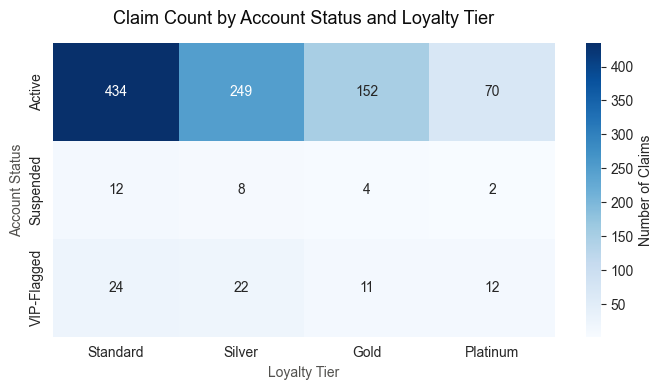

In [67]:
# Loyalty tiers ordered by LoyaltyTierOrdinal (Standard=0 .. Platinum=3), not alphabetically
tier_order = (df[['LoyaltyTier', 'LoyaltyTierOrdinal']]
              .drop_duplicates()
              .sort_values('LoyaltyTierOrdinal')['LoyaltyTier']
              .tolist())

status_tier_counts = pd.crosstab(df['AccountStatus'], df['LoyaltyTier'])[tier_order]
display(status_tier_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(status_tier_counts, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Claims'}, ax=ax)
ax.set_title('Claim Count by Account Status and Loyalty Tier', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('Loyalty Tier', color='#52514e')
ax.set_ylabel('Account Status', color='#52514e')
plt.tight_layout()
plt.show()

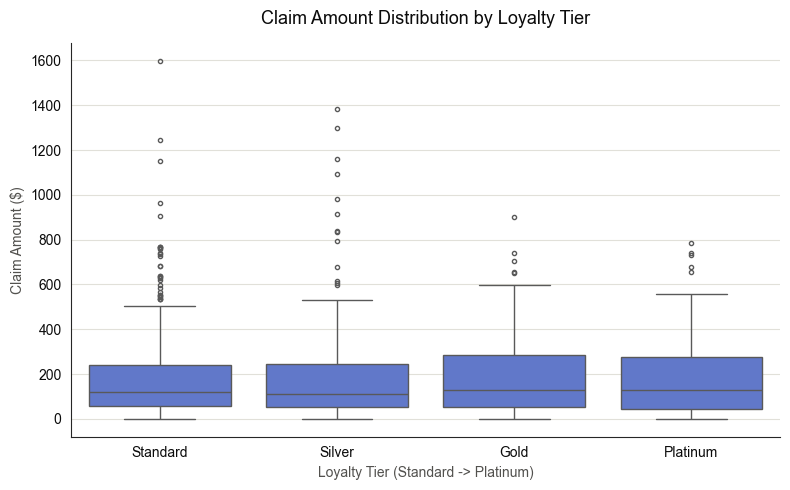

,count,mean,std,min,25%,50%,75%,max
LoyaltyTier,,,,,,,,
Standard,470.0,180.140809,190.498564,0.31,56.1775,121.005,239.6300,1596.15
Silver,279.0,182.557419,211.267315,0.48,51.7200,112.800,245.4700,1382.10
Gold,167.0,185.499701,174.810205,0.23,52.5050,128.770,284.1500,898.94
Platinum,84.0,196.002500,198.887587,0.01,46.0725,127.655,277.1875,786.25


In [68]:
# Claim amount distribution by loyalty tier, kept in tier rank order
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='LoyaltyTier', y='ClaimAmount', order=tier_order, color='#4f6fdb', ax=ax, fliersize=3)

ax.set_title('Claim Amount Distribution by Loyalty Tier', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('Loyalty Tier (Standard -> Platinum)', color='#52514e')
ax.set_ylabel('Claim Amount ($)', color='#52514e')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(colors='#0b0b0b', labelsize=10)
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

df.groupby('LoyaltyTier')['ClaimAmount'].describe().loc[tier_order]

## 9. Claim Distribution Across Booking Channels

How many claims originate from each `BookingChannel` (where the original travel booking was made — separate from `ClaimSubmissionChannel`, which is how the claim itself was filed).

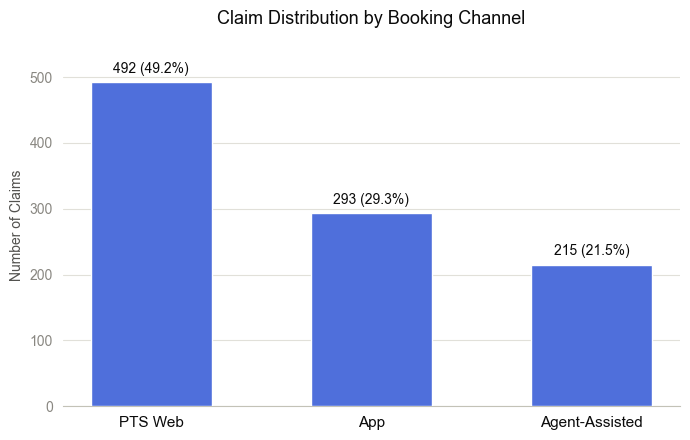

In [69]:
booking_channel_counts = df['BookingChannel'].value_counts()
total = booking_channel_counts.sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(booking_channel_counts.index, booking_channel_counts.values, color='#4f6fdb', width=0.55, zorder=3)

for bar, count in zip(bars, booking_channel_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
             f"{count} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10, color='#0b0b0b')

ax.set_title('Claim Distribution by Booking Channel', fontsize=13, color='#0b0b0b', pad=14)
ax.set_ylabel('Number of Claims', color='#52514e')
ax.set_xlabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=11)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

## 10. How Many Claims Were Family Bookings?

`IsFamilyBooking` is a boolean flag on the underlying booking. Show the overall split, plus how claim status differs between family and non-family bookings.

Family bookings: 439 (43.9%)
Non-family bookings: 561 (56.1%)


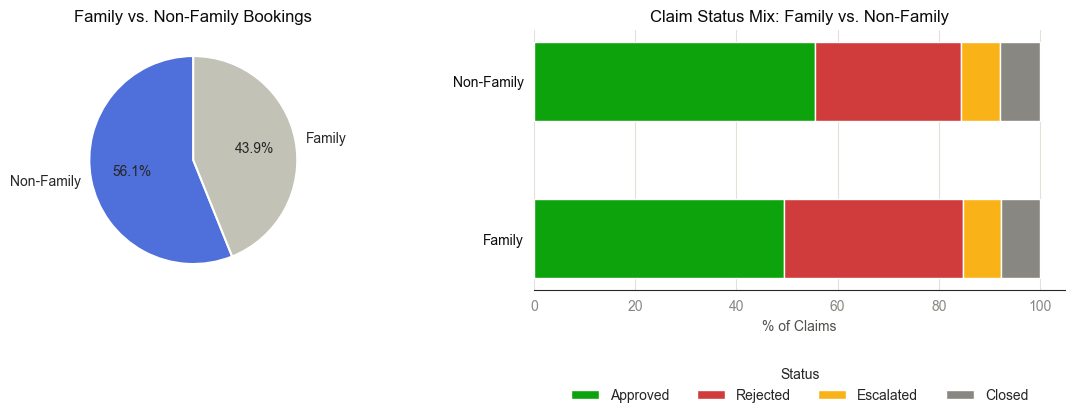

In [70]:
family_counts = df['IsFamilyBooking'].value_counts()
family_pct = (family_counts / family_counts.sum() * 100).round(1)
print(f"Family bookings: {family_counts.get(True, 0)} ({family_pct.get(True, 0)}%)")
print(f"Non-family bookings: {family_counts.get(False, 0)} ({family_pct.get(False, 0)}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: simple pie of family vs non-family share
colors_family = ['#4f6fdb', '#c3c2b7']
axes[0].pie(family_counts.values, labels=['Family' if v else 'Non-Family' for v in family_counts.index],
            autopct='%1.1f%%', colors=colors_family, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Family vs. Non-Family Bookings', fontsize=12, color='#0b0b0b')

# Right: claim status mix within family vs non-family bookings
family_status = pd.crosstab(df['IsFamilyBooking'].map({True: 'Family', False: 'Non-Family'}), df['ClaimStatus'])
family_status = family_status[[c for c in status_colors if c in family_status.columns]]
family_status_pct = family_status.div(family_status.sum(axis=1), axis=0) * 100

left = pd.Series(0.0, index=family_status_pct.index)
for status in family_status_pct.columns:
    axes[1].barh(family_status_pct.index, family_status_pct[status], left=left,
                 color=status_colors.get(status, '#52514e'), label=status, height=0.5, zorder=3)
    left = left + family_status_pct[status]

axes[1].set_title('Claim Status Mix: Family vs. Non-Family', fontsize=12, color='#0b0b0b')
axes[1].set_xlabel('% of Claims', color='#52514e')
axes[1].spines[['top', 'right', 'left']].set_visible(False)
axes[1].tick_params(axis='y', colors='#0b0b0b', labelsize=10)
axes[1].tick_params(axis='x', colors='#898781')
axes[1].xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
axes[1].set_axisbelow(True)
axes[1].legend(title='Status', loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)

plt.tight_layout()
plt.show()

## 11. Distribution of Rental Duration Days and Nights Duration

`RentalDurationDays` only applies to Car bookings and `NightsDuration` only to Cruise bookings, so both are mostly null across the full dataset (875 and 909 nulls out of 1,000 respectively) — each histogram below is drawn only over its applicable rows.

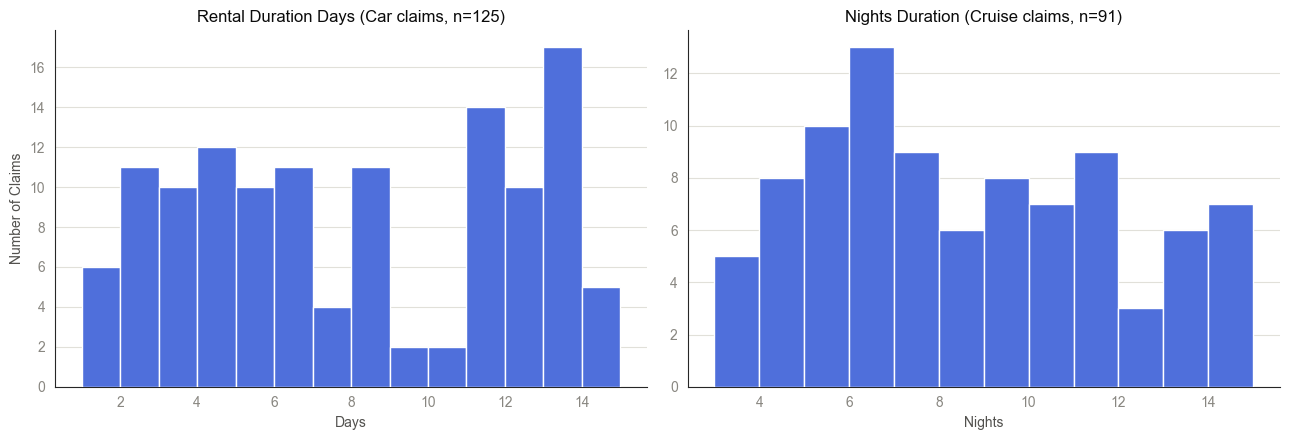

In [71]:
rental_days = df['RentalDurationDays'].dropna()
nights = df['NightsDuration'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(rental_days, bins=range(int(rental_days.min()), int(rental_days.max()) + 2),
             color='#4f6fdb', edgecolor='white', zorder=3)
axes[0].set_title(f'Rental Duration Days (Car claims, n={len(rental_days)})', fontsize=12, color='#0b0b0b')
axes[0].set_xlabel('Days', color='#52514e')
axes[0].set_ylabel('Number of Claims', color='#52514e')

axes[1].hist(nights, bins=range(int(nights.min()), int(nights.max()) + 2),
             color='#4f6fdb', edgecolor='white', zorder=3)
axes[1].set_title(f'Nights Duration (Cruise claims, n={len(nights)})', fontsize=12, color='#0b0b0b')
axes[1].set_xlabel('Nights', color='#52514e')
axes[1].set_ylabel('')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(colors='#898781')
    ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 12. Distribution of Claim Submission Timing Relative to Travel

`ClaimSubmittedRelativeToTravel` indicates whether the claim was filed Before, During, or After the trip.

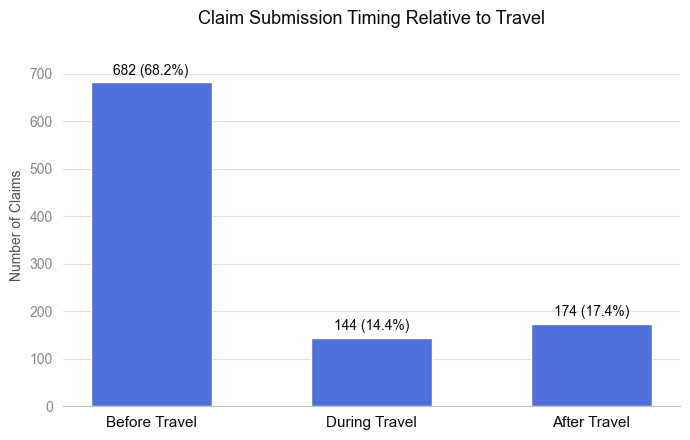

In [72]:
relative_order = ['Before Travel', 'During Travel', 'After Travel']
relative_counts = df['ClaimSubmittedRelativeToTravel'].value_counts().reindex(relative_order)
total = relative_counts.sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(relative_counts.index, relative_counts.values, color='#4f6fdb', width=0.55, zorder=3)

for bar, count in zip(bars, relative_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
             f"{count} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10, color='#0b0b0b')

ax.set_title('Claim Submission Timing Relative to Travel', fontsize=13, color='#0b0b0b', pad=14)
ax.set_ylabel('Number of Claims', color='#52514e')
ax.set_xlabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=11)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

## 13. Booking Month Distribution by Booking Type (Stacked Bar)

Parse `BookingDate` into a Year-Month period and stack claim counts by `BookingType` (Car, Cruise, Flight, Hotel/Lodging, Package) to see both booking volume trends and the type mix over time.

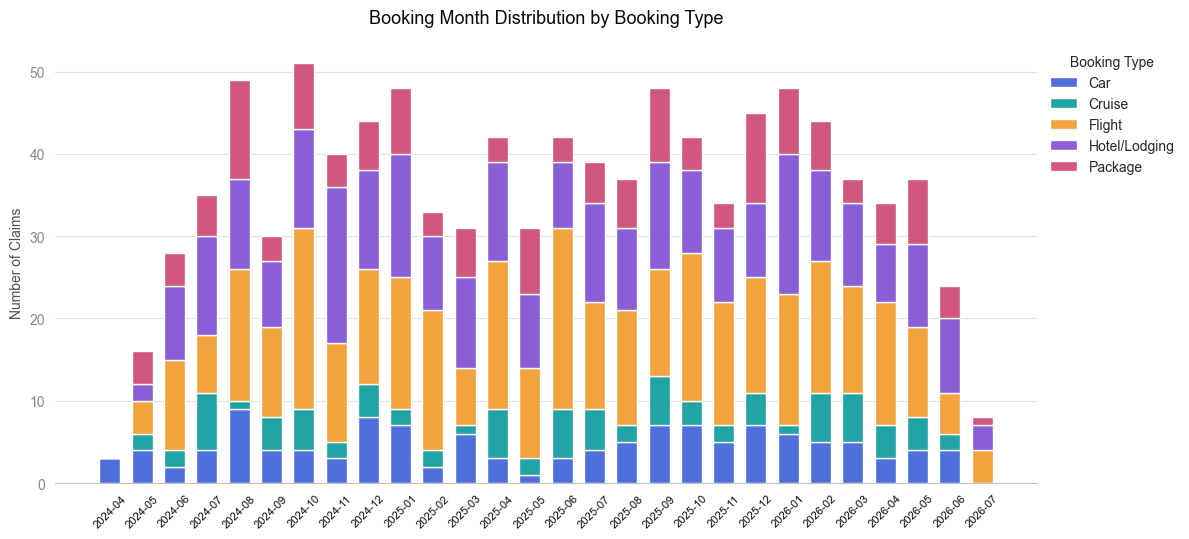

In [73]:
df['BookingDate'] = pd.to_datetime(df['BookingDate'])
df['BookingYearMonth'] = df['BookingDate'].dt.to_period('M').astype(str)

booking_type_colors = {
    'Car': '#4f6fdb', 'Cruise': '#20a4a4', 'Flight': '#f2a33d',
    'Hotel/Lodging': '#8a5fd6', 'Package': '#d0577e',
}

booking_month_type = pd.crosstab(df['BookingYearMonth'], df['BookingType']).sort_index()
booking_month_type = booking_month_type[[c for c in booking_type_colors if c in booking_month_type.columns]]

fig, ax = plt.subplots(figsize=(12, 5.5))
bottom = pd.Series(0, index=booking_month_type.index)
for btype in booking_month_type.columns:
    ax.bar(booking_month_type.index, booking_month_type[btype], bottom=bottom,
           color=booking_type_colors.get(btype, '#52514e'), label=btype, width=0.65, zorder=3)
    bottom = bottom + booking_month_type[btype]

ax.set_title('Booking Month Distribution by Booking Type', fontsize=13, color='#0b0b0b', pad=14)
ax.set_ylabel('Number of Claims', color='#52514e')
ax.set_xlabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=8, rotation=45)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Booking Type', loc='upper left', bbox_to_anchor=(1.0, 1.0), frameon=False)
plt.tight_layout()
plt.show()

## 14. Distribution Against Booking Special Considerations

`BookingSpecialConsiderations` is null for bookings with no special consideration (289 of 1,000); those are grouped into an explicit "None" category rather than dropped, so the chart reflects the full population.

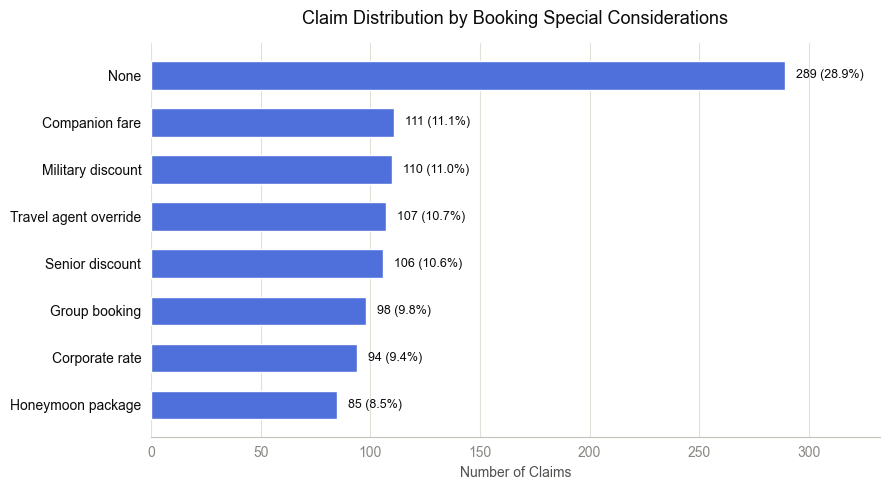

In [74]:
special_counts = df['BookingSpecialConsiderations'].fillna('None').value_counts()
total = special_counts.sum()

fig, ax = plt.subplots(figsize=(9, 5))
order = special_counts.sort_values(ascending=True)
bars = ax.barh(order.index, order.values, color='#4f6fdb', height=0.6, zorder=3)

for bar, count in zip(bars, order.values):
    pct = count / total * 100
    ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
             f"{count} ({pct:.1f}%)", va='center', ha='left', fontsize=9, color='#0b0b0b')

ax.set_title('Claim Distribution by Booking Special Considerations', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('Number of Claims', color='#52514e')
ax.set_ylabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=10)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## 15. Statistical Correlation Analysis with `IsApproved`

Two families of predictors need two different statistics, since `IsApproved` is binary:

- **Numeric features** -> point-biserial correlation (mathematically identical to Pearson's r against a 0/1 variable), which gives both direction and strength.
- **Categorical features** -> Cramer's V (derived from a chi-square test), which only gives strength (0-1), not direction, since categories have no inherent order.

`ApprovedAmount`, `ApprovedPoints`, `RefundAmount`, `RefundPoints`, and `RefundMethod` are excluded on purpose: they are only populated *after* a claim is approved (each is exactly 0/null for every rejected claim), so they are consequences of `IsApproved`, not predictors of it, and would trivially "correlate" at ~1.0. `ApprovalOrRejectionReason` and the free-text fields are excluded for the same reason — they restate the decision rather than predict it. Identifier-like numeric columns (`AddressZip`) and fully-null columns (`CheckInDate`, `CheckOutDate`) are excluded as uninformative.

In [75]:
from scipy.stats import pointbiserialr

df['IsApproved_num'] = (df['IsApproved'] == 'Yes').astype(int)

# Columns that are a consequence of the decision (leakage) or non-informative identifiers/empty columns
leakage_or_uninformative = [
    'ApprovedAmount', 'ApprovedPoints', 'RefundAmount', 'RefundPoints',
    'AddressZip', 'CheckInDate', 'CheckOutDate',
]

numeric_cols = df.select_dtypes(include=[np.number]).columns
candidate_numeric = [c for c in numeric_cols if c not in leakage_or_uninformative + ['IsApproved_num']]

results = []
for col in candidate_numeric:
    valid = df[[col, 'IsApproved_num']].dropna()
    # need enough observations and non-zero variance for the statistic to be meaningful
    if len(valid) >= 30 and valid[col].std() > 0:
        r, p = pointbiserialr(valid[col], valid['IsApproved_num'])
        results.append({'Feature': col, 'Correlation': r, 'p_value': p, 'N': len(valid)})

numeric_corr = pd.DataFrame(results).set_index('Feature').sort_values('Correlation', key=lambda s: s.abs(), ascending=False)
numeric_corr['Significant (p<0.05)'] = numeric_corr['p_value'] < 0.05
numeric_corr.round(4)

,Correlation,p_value,N,Significant (p<0.05)
Feature,,,,
LegitimacyScore,0.5779,0.0000,1000,True
AttachmentCompletenessScore,0.2156,0.0000,1000,True
RentalDurationDays,-0.1338,0.1369,125,False
AttachmentCount,0.1276,0.0001,1000,True
PriorApprovalRate,0.1195,0.0002,1000,True
DaysClaimToTravelStart,0.1177,0.0002,1000,True
NightsDuration,0.0907,0.3927,91,False
RateDifferencePercent,-0.0860,0.0065,1000,True
StarRating,0.0841,0.1611,279,False


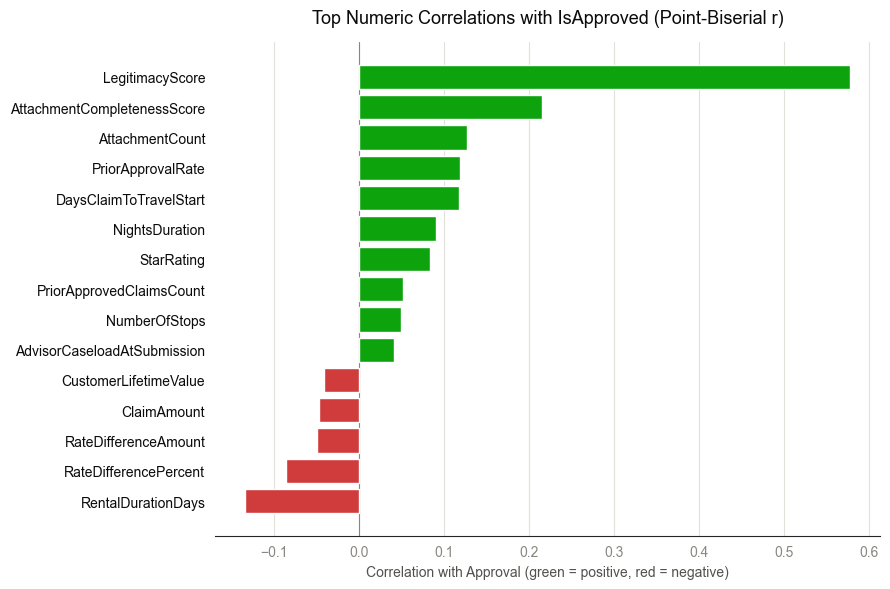

In [76]:
# Bar chart of the top 15 numeric correlations with IsApproved, direction shown by color
top_numeric = numeric_corr.head(15).sort_values('Correlation')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#0ca30c' if v > 0 else '#d03b3b' for v in top_numeric['Correlation']]
ax.barh(top_numeric.index, top_numeric['Correlation'], color=colors, zorder=3)

ax.axvline(0, color='#898781', linewidth=0.8)
ax.set_title('Top Numeric Correlations with IsApproved (Point-Biserial r)', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('Correlation with Approval (green = positive, red = negative)', color='#52514e')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=10)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [77]:
def cramers_v(col, target):
    """Bias-corrected Cramer's V association strength between a categorical column and the target."""
    valid = pd.DataFrame({'col': col, 'target': target}).dropna()
    ct = pd.crosstab(valid['col'], valid['target'])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan, np.nan, len(valid)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return (chi2 / (n * k)) ** 0.5, p, n

# Categorical / boolean predictors, excluding free text, IDs, and decision-consequence fields
categorical_cols = [
    'ClaimSubmissionChannel', 'ProofTypeFilled', 'RestrictionsMatchFlag', 'MinimumClaimThresholdMet',
    'SLABreached', 'IsMultiSegmentBooking', 'BlackoutDateOrExcludedFare', 'IsFamilyBooking',
    'HasValidBetterRateURL', 'LoyaltyTier', 'AccountStatus', 'BookingType', 'BookingChannel',
    'ClaimSubmittedRelativeToTravel', 'SeasonalityFlag', 'FareOrRatePlanFlexibility',
]

cat_results = []
for col in categorical_cols:
    v, p, n = cramers_v(df[col], df['IsApproved'])
    if not np.isnan(v):
        cat_results.append({'Feature': col, "Cramer's V": v, 'p_value': p, 'N': n})

cat_corr = pd.DataFrame(cat_results).set_index('Feature').sort_values("Cramer's V", ascending=False)
cat_corr['Significant (p<0.05)'] = cat_corr['p_value'] < 0.05
cat_corr.round(4)

,Cramer's V,p_value,N,Significant (p<0.05)
Feature,,,,
RestrictionsMatchFlag,0.3953,0.0000,1000,True
ProofTypeFilled,0.1654,0.0000,1000,True
MinimumClaimThresholdMet,0.1607,0.0000,1000,True
ClaimSubmittedRelativeToTravel,0.1557,0.0000,1000,True
BookingType,0.0830,0.1416,1000,False
FareOrRatePlanFlexibility,0.0819,0.0816,1000,False
BookingChannel,0.0815,0.0362,1000,True
IsFamilyBooking,0.0666,0.0351,1000,True
HasValidBetterRateURL,0.0599,0.0581,1000,False


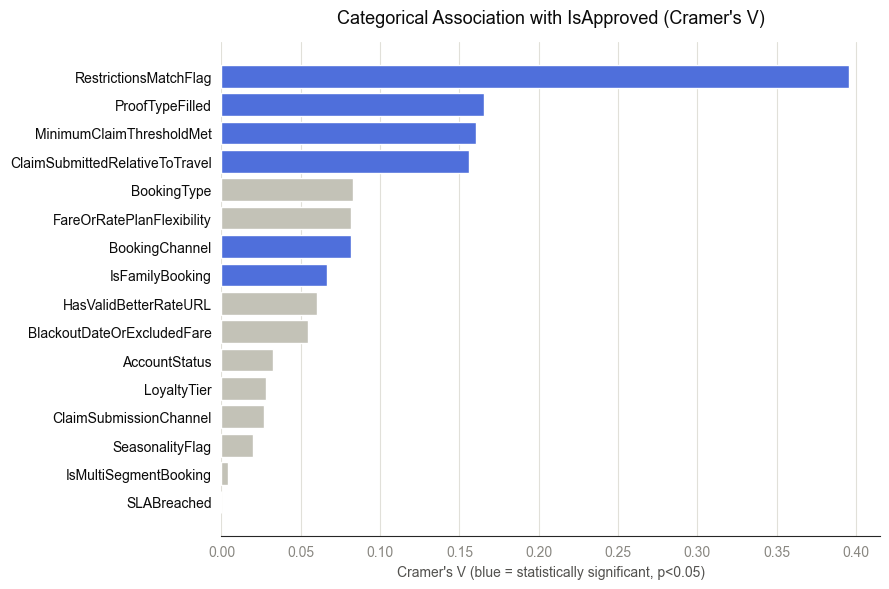

In [78]:
# Bar chart of categorical association strength (Cramer's V has no direction, unlike Pearson/point-biserial r)
plot_cat = cat_corr.sort_values("Cramer's V")

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4f6fdb' if sig else '#c3c2b7' for sig in plot_cat['Significant (p<0.05)']]
ax.barh(plot_cat.index, plot_cat["Cramer's V"], color=colors, zorder=3)

ax.set_title("Categorical Association with IsApproved (Cramer's V)", fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel("Cramer's V (blue = statistically significant, p<0.05)", color='#52514e')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=10)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Summary of Correlation Findings

**Numeric features** (point-biserial r, |r| ranked, statistically significant at p<0.05):
1. `LegitimacyScore` — r = 0.578 (strongest predictor by far)
2. `AttachmentCompletenessScore` — r = 0.216
3. `AttachmentCount` — r = 0.128
4. `PriorApprovalRate` — r = 0.120
5. `DaysClaimToTravelStart` — r = 0.118
6. `RateDifferencePercent` — r = -0.086 (larger % gap vs. our rate is *mildly* associated with lower approval odds)

All other numeric features (`ClaimAmount`, `BookingAmount`, `AdvisorTenureMonths`, `CustomerLifetimeValue`, `LoyaltyTierOrdinal`, SLA/timing metrics, etc.) show negligible, non-significant correlation with approval.

**Categorical features** (Cramer's V ranked, statistically significant at p<0.05):
1. `RestrictionsMatchFlag` — V = 0.395 (by far the strongest categorical driver)
2. `ProofTypeFilled` — V = 0.165
3. `MinimumClaimThresholdMet` — V = 0.161
4. `ClaimSubmittedRelativeToTravel` — V = 0.156
5. `BookingChannel` — V = 0.082
6. `IsFamilyBooking` — V = 0.067

Notably, `AccountStatus`, `LoyaltyTier`, `SeasonalityFlag`, `IsMultiSegmentBooking`, `SLABreached`, and — confirming the Section 2 chi-square test — **`ClaimSubmissionChannel`** (V = 0.027, p = 0.947) show **no meaningful association** with approval outcome.

**Takeaway:** Claim approval is driven almost entirely by claim-quality signals — whether the claim meets program restrictions (`RestrictionsMatchFlag`), the underlying `LegitimacyScore`, documentation completeness (`AttachmentCompletenessScore`/`AttachmentCount`/`ProofTypeFilled`), and whether the minimum claim threshold is met — not by customer attributes (loyalty tier, account status) or how/where the claim was submitted. This is a reassuring pattern operationally: it suggests the adjudication process is evaluating claims on their merits rather than on customer or channel bias.

## 16. Feature Engineering for Predicting `IsApproved`

Section 15 measured how the **raw columns** associate with the target. This section turns that
diagnosis into a **model-ready feature set**: it separates fields that are genuinely known at
claim-intake time from post-decision leakage, rebuilds the Section-6 "legitimacy" drivers as
explicit engineered features, adds temporal / monetary / documentation / customer-history / text
features, assembles a one-hot-encoded matrix, and validates the result with correlations and a
baseline classifier.

**Leakage guardrails.** Three groups of columns are held out of the feature matrix:

| Group | Columns | Why excluded |
| :-- | :-- | :-- |
| Post-decision outcome | `ClaimStatus`, `ClaimDecisionDate`, `ApprovalOrRejectionReason`, `Approved*`, `Refund*`, `InternalAdvisorNotes` | Only exist *because* a decision was made — they restate the label. |
| Post-decision operations | `TimeToAdjudicateMinutes`, `SLAHoursElapsed`, `SLABreached`, `AdjudicationLaborCost` | Measured during/after adjudication, not available when a new claim lands. |
| Generator-internal | `LegitimacyScore` | The hidden 0–100 score the synthetic label was sampled from (data prompt Section 6). Using it directly is circular; instead we **rebuild its components from raw fields** and treat its correlation with the target (r = 0.58) as the ceiling to aim for. |


In [37]:
import pandas as pd
import numpy as np

# Target: 1 = Approved, 0 = Not Approved
y = (df['IsApproved'] == 'Yes').astype(int)

# (a) hard leakage - only known AFTER the advisor decides
LEAKAGE = [
    'ClaimStatus', 'ClaimDecisionDate', 'IsApproved', 'IsApproved_num', 'ApprovalOrRejectionReason',
    'InternalAdvisorNotes',
    'ApprovedAmount', 'ApprovedPoints', 'RefundAmount', 'RefundPoints', 'RefundMethod',
    'TimeToAdjudicateMinutes', 'SLAHoursElapsed', 'SLABreached', 'AdjudicationLaborCost',
]
# (b) generator-internal construct (kept out; used only as a reference ceiling later)
GENERATOR_INTERNAL = ['LegitimacyScore']
# (c) identifiers / raw free-text / empty / constant columns - no standalone signal
IDS_ETC = [
    'CaseID', 'AssignedAdvisorID', 'CustomerID', 'BookingID',
    'FirstName', 'LastName', 'Phone', 'Email', 'AddressStreet', 'AddressZip', 'AddressCountry',
    'BookingCurrency', 'SLATargetHours', 'AdvisorCaseloadAtSubmission',
    'CheckInDate', 'CheckOutDate', 'PassengerDetails', 'SegmentList', 'BetterRateURL',
    'Attachment1', 'Attachment2', 'Attachment3', 'Attachment4', 'Attachment5',
]

# make sure every date/timestamp column is parsed (some already were in earlier sections)
for col in ['ClaimSubmissionDate', 'BookingDate', 'TravelStartDate', 'TravelEndDate',
            'LoyaltyMemberSinceDate']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# fe = the engineered NUMERIC feature frame; categoricals are one-hot encoded later
fe = pd.DataFrame(index=df.index)
print(f"{len(LEAKAGE)} leakage cols, {len(GENERATOR_INTERNAL)} generator-internal, "
      f"{len(IDS_ETC)} id/text/empty cols held out")


15 leakage cols, 1 generator-internal, 24 id/text/empty cols held out


### 16.1 Reconstruct the eligibility drivers (data-prompt Section 6 logic)

The synthetic label was generated from a weighted "legitimacy" score built out of proof quality,
restrictions match, rate-difference plausibility, submission timing, the minimum-threshold check,
and the customer's prior approval rate. These are exactly the features to make explicit.


In [38]:
# --- proof / documentation strength ---------------------------------
fe['proof_verified']          = (df['ProofQualityFlag'] == 'Verified').astype(int)
fe['proof_insufficient']      = (df['ProofQualityFlag'] == 'Insufficient').astype(int)
fe['proof_quality_ord']       = df['ProofQualityFlag'].map({'Insufficient': 0, 'Ambiguous': 1, 'Verified': 2})
fe['has_attachments']         = (df['AttachmentCount'] >= 1).astype(int)
fe['multi_attachments']       = (df['AttachmentCount'] >= 2).astype(int)
fe['strong_proof']            = ((df['AttachmentCount'] >= 1) & (df['ProofQualityFlag'] == 'Verified')).astype(int)
fe['proof_type_missing']      = df['ProofType'].isna().astype(int)
fe['attachment_count']        = df['AttachmentCount']
fe['attachment_completeness'] = df['AttachmentCompletenessScore']
fe['attachment_density']      = df['AttachmentCompletenessScore'] * df['AttachmentCount']

# --- restrictions / program eligibility ----------------------------
fe['restrictions_match']      = df['RestrictionsMatchFlag'].astype(int)
fe['threshold_met']           = df['MinimumClaimThresholdMet'].astype(int)
fe['has_valid_url']           = df['HasValidBetterRateURL'].astype(int)
fe['blackout_or_excluded']    = df['BlackoutDateOrExcludedFare'].astype(int)

# --- rate-difference plausibility band (Sec 6: ~3-40% plausible, >~60% implausible) ---
rdp = df['RateDifferencePercent']
fe['rate_diff_pct']           = rdp
fe['rate_diff_amount']        = df['RateDifferenceAmount']
fe['rate_diff_in_band']       = rdp.between(0.03, 0.40).astype(int)
fe['rate_diff_below_min']     = (rdp < 0.03).astype(int)
fe['rate_diff_implausible']   = (rdp > 0.60).astype(int)

# --- submission timing relative to travel --------------------------
fe['submitted_before_travel'] = (df['ClaimSubmittedRelativeToTravel'] == 'Before Travel').astype(int)
fe['submitted_during_travel'] = (df['ClaimSubmittedRelativeToTravel'] == 'During Travel').astype(int)
fe['submitted_after_travel']  = (df['ClaimSubmittedRelativeToTravel'] == 'After Travel').astype(int)

# --- customer prior track record ----------------------------------
fe['prior_approval_rate']     = df['PriorApprovalRate']
fe['prior_claims_count']      = df['PriorClaimsCount']
fe['prior_approved_count']    = df['PriorApprovedClaimsCount']
fe['prior_rejected_count']    = (df['PriorClaimsCount'] - df['PriorApprovedClaimsCount']).clip(lower=0)
fe['is_first_time_claimant']  = (df['PriorClaimsCount'] == 0).astype(int)

fe.filter(regex='proof|restrict|rate_diff|submitted|prior').head()


,proof_verified,proof_insufficient,proof_quality_ord,strong_proof,proof_type_missing,restrictions_match,rate_diff_pct,rate_diff_amount,rate_diff_in_band,rate_diff_below_min,rate_diff_implausible,submitted_before_travel,submitted_during_travel,submitted_after_travel,prior_approval_rate,prior_claims_count,prior_approved_count,prior_rejected_count
0,0,1,0,0,1,1,0.6850,301.94,0,0,1,1,0,0,0.5,0,0,0
1,0,0,1,0,0,1,0.3761,75.76,1,0,0,0,1,0,0.5,0,0,0
2,0,1,0,0,1,1,0.2700,124.41,1,0,0,1,0,0,0.5,0,0,0
3,0,1,0,0,1,0,0.0853,69.01,1,0,0,1,0,0,0.5,0,0,0
4,0,1,0,0,1,0,0.3442,152.62,1,0,0,1,0,0,0.5,0,0,0


In [39]:
# Composite scores mirroring the Section-6 legitimacy logic:
# count how many "approve" signals fire vs how many "reject" red flags fire.
POS_FLAGS = ['strong_proof', 'restrictions_match', 'rate_diff_in_band',
             'submitted_before_travel', 'threshold_met', 'has_valid_url']
NEG_FLAGS = ['proof_insufficient', 'rate_diff_implausible', 'rate_diff_below_min',
             'submitted_after_travel', 'blackout_or_excluded']

fe['eligibility_positive_score'] = fe[POS_FLAGS].sum(axis=1)          # 0..6
fe['eligibility_redflag_count']  = fe[NEG_FLAGS].sum(axis=1)          # 0..5
fe['eligibility_net_score']      = fe['eligibility_positive_score'] - fe['eligibility_redflag_count']
# soft reputation bonus: prior approval rate re-centred to [-1, +1]
fe['eligibility_net_score_plus'] = fe['eligibility_net_score'] + (df['PriorApprovalRate'].fillna(0.5) - 0.5) * 2

fe[['eligibility_positive_score', 'eligibility_redflag_count',
    'eligibility_net_score', 'eligibility_net_score_plus']].describe().round(2)


,eligibility_positive_score,eligibility_redflag_count,eligibility_net_score,eligibility_net_score_plus
count,1000.00,1000.00,1000.00,1000.00
mean,4.14,0.65,3.50,3.66
std,1.12,0.72,1.57,1.70
min,1.00,0.00,-2.00,-2.00
25%,3.00,0.00,2.00,2.00
50%,4.00,1.00,4.00,4.00
75%,5.00,1.00,5.00,5.00
max,6.00,4.00,6.00,7.00


### 16.2 Temporal features

Derived from the parsed date columns: *when* in the calendar the claim was filed, how far ahead of
travel the booking was made, how long the customer has been a loyalty member, and whether the claim
was filed after travel had already started.


In [40]:
sub = df['ClaimSubmissionDate']
fe['submission_month']           = sub.dt.month
fe['submission_quarter']         = sub.dt.quarter
fe['submission_dayofweek']       = sub.dt.dayofweek
fe['submission_is_weekend']      = (sub.dt.dayofweek >= 5).astype(int)
fe['submission_hour']            = sub.dt.hour
fe['booking_lead_days']          = (df['TravelStartDate'] - df['BookingDate']).dt.days
fe['loyalty_tenure_days']        = (df['ClaimSubmissionDate'] - df['LoyaltyMemberSinceDate']).dt.days
fe['days_booking_to_claim']      = df['DaysBookingToClaim']
fe['days_claim_to_travel']       = df['DaysClaimToTravelStart']
fe['claim_after_travel_started'] = (df['DaysClaimToTravelStart'] < 0).astype(int)
fe['trip_duration_days']         = df['TripDurationDays']

fe.filter(regex='submission|booking_lead|loyalty_tenure|days_|trip_dur|claim_after').describe().round(1)


,submission_month,submission_quarter,submission_dayofweek,submission_is_weekend,submission_hour,booking_lead_days,loyalty_tenure_days,days_booking_to_claim,days_claim_to_travel,claim_after_travel_started,trip_duration_days
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,6.6,2.5,3.1,0.3,11.4,84.6,1469.3,60.4,24.2,0.3,4.9
std,3.4,1.1,2.0,0.5,6.7,51.5,1065.4,34.3,37.2,0.4,3.4
min,1.0,1.0,0.0,0.0,0.0,-44.0,-685.0,1.0,-59.0,0.0,1.0
25%,4.0,2.0,1.0,0.0,5.0,47.0,570.8,31.0,-1.0,0.0,3.0
50%,7.0,3.0,3.0,0.0,12.0,87.0,1461.5,60.0,21.5,0.0,4.0
75%,10.0,4.0,5.0,1.0,17.0,119.0,2372.0,90.2,55.0,1.0,7.0
max,12.0,4.0,6.0,1.0,23.0,204.0,3553.0,119.0,89.0,1.0,14.0


### 16.3 Monetary & ratio features

Absolute dollar amounts are heavy-tailed, so log transforms are added alongside the raw values.
Ratios normalise a claim against the size of its own booking.


In [41]:
fe['claim_amount']           = df['ClaimAmount']
fe['claim_amount_log']       = np.log1p(df['ClaimAmount'])
fe['booking_amount']         = df['BookingAmount']
fe['booking_amount_log']     = np.log1p(df['BookingAmount'])
fe['claim_to_booking_ratio'] = df['ClaimAmount'] / df['BookingAmount']
fe['better_rate_to_booking'] = df['BetterRateAmount'] / df['BookingAmount']
fe['has_points_claim']       = (df['ClaimPoints'] > 0).astype(int)
fe['claim_points']           = df['ClaimPoints']
fe['clv']                    = df['CustomerLifetimeValue']
fe['clv_log']                = np.log1p(df['CustomerLifetimeValue'])

fe[['claim_amount', 'claim_amount_log', 'claim_to_booking_ratio',
    'better_rate_to_booking', 'clv', 'clv_log']].describe().round(2)


,claim_amount,claim_amount_log,claim_to_booking_ratio,better_rate_to_booking,clv,clv_log
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,183.04,4.63,0.31,0.69,1875.93,7.19
std,194.53,1.27,0.22,0.22,1887.72,0.82
min,0.01,0.01,0.00,0.05,132.95,4.90
25%,52.43,3.98,0.13,0.55,738.24,6.61
50%,121.22,4.81,0.28,0.73,1339.53,7.20
75%,249.58,5.52,0.44,0.87,2333.44,7.76
max,1596.15,7.38,1.03,1.00,18443.66,9.82


### 16.4 Customer / booking context & text features

Customer standing and booking shape, plus lightweight features mined from the free-text
`CustomerComments` (which the customer supplies with the claim). `InternalAdvisorNotes` is **not**
mined — it is written during adjudication and would leak the outcome.


In [42]:
# --- customer & booking context ---
fe['loyalty_tier_ordinal']  = df['LoyaltyTierOrdinal']
fe['account_suspended']     = (df['AccountStatus'] == 'Suspended').astype(int)
fe['account_vip']           = (df['AccountStatus'] == 'VIP-Flagged').astype(int)
fe['is_family_booking']     = df['IsFamilyBooking'].astype(int)
fe['is_multisegment']       = df['IsMultiSegmentBooking'].astype(int)
fe['number_of_passengers']  = df['NumberOfPassengers']
fe['advisor_tenure_months'] = df['AdvisorTenureMonths']

# --- text features from CustomerComments only ---
cc = df['CustomerComments'].fillna('')
fe['has_customer_comment']   = (cc.str.len() > 0).astype(int)
fe['comment_char_len']       = cc.str.len()
fe['comment_word_count']     = cc.str.split().str.len().fillna(0).astype(int)
fe['comment_has_url']        = cc.str.contains(r'http|www\.|\.com', case=False, regex=True).astype(int)
fe['comment_mentions_price'] = cc.str.contains(r'price|cheaper|rate|cost|\$', case=False, regex=True).astype(int)

print("Total engineered numeric features:", fe.shape[1])
fe.filter(regex='comment|account|is_family|is_multi').head()


Total engineered numeric features: 64


,account_suspended,account_vip,is_family_booking,is_multisegment,has_customer_comment,comment_char_len,comment_word_count,comment_has_url,comment_mentions_price
0,0,0,0,0,1,61,11,0,1
1,0,0,1,0,0,0,0,0,0
2,0,1,1,0,1,56,11,0,1
3,0,0,0,0,1,72,13,0,1
4,1,0,0,0,1,65,11,0,1


### 16.5 Assemble the model-ready matrix

Categorical fields are one-hot encoded (`col=value` column names) and concatenated with the
engineered numeric frame. `ProofType` and `BookingSpecialConsiderations` nulls become explicit
`"No Proof"` / `"None"` categories, since the *absence* is itself informative.


In [43]:
CATEGORICALS = {
    'BookingType':                    df['BookingType'],
    'BookingChannel':                 df['BookingChannel'],
    'ClaimSubmissionChannel':         df['ClaimSubmissionChannel'],
    'ClaimSubmittedRelativeToTravel': df['ClaimSubmittedRelativeToTravel'],
    'ProofType':                      df['ProofType'].fillna('No Proof'),
    'ProofQualityFlag':               df['ProofQualityFlag'],
    'LoyaltyTier':                    df['LoyaltyTier'],
    'AccountStatus':                  df['AccountStatus'],
    'SeasonalityFlag':                df['SeasonalityFlag'],
    'FareOrRatePlanFlexibility':      df['FareOrRatePlanFlexibility'],
    'BetterRateVendorName':           df['BetterRateVendorName'],
    'BookingSpecialConsiderations':   df['BookingSpecialConsiderations'].fillna('None'),
}
cat_df = pd.get_dummies(pd.DataFrame(CATEGORICALS), prefix_sep='=', dtype=int)

X = pd.concat([fe, cat_df], axis=1).replace([np.inf, -np.inf], np.nan)

print(f"Engineered numeric features : {fe.shape[1]}")
print(f"One-hot categorical features: {cat_df.shape[1]}")
print(f"Final feature matrix X      : {X.shape}")
print(f"Target positive rate        : {y.mean():.3f}")
X.head()


Engineered numeric features : 64
One-hot categorical features: 55
Final feature matrix X      : (1000, 119)
Target positive rate        : 0.632


,proof_verified,proof_insufficient,proof_quality_ord,has_attachments,multi_attachments,strong_proof,proof_type_missing,attachment_count,attachment_completeness,attachment_density,restrictions_match,threshold_met,has_valid_url,blackout_or_excluded,rate_diff_pct,rate_diff_amount,rate_diff_in_band,rate_diff_below_min,rate_diff_implausible,submitted_before_travel,submitted_during_travel,submitted_after_travel,prior_approval_rate,prior_claims_count,prior_approved_count,prior_rejected_count,is_first_time_claimant,eligibility_positive_score,eligibility_redflag_count,eligibility_net_score,eligibility_net_score_plus,submission_month,submission_quarter,submission_dayofweek,submission_is_weekend,submission_hour,booking_lead_days,loyalty_tenure_days,days_booking_to_claim,days_claim_to_travel,claim_after_travel_started,trip_duration_days,claim_amount,claim_amount_log,booking_amount,booking_amount_log,claim_to_booking_ratio,better_rate_to_booking,has_points_claim,claim_points,clv,clv_log,loyalty_tier_ordinal,account_suspended,account_vip,is_family_booking,is_multisegment,number_of_passengers,advisor_tenure_months,has_customer_comment,comment_char_len,comment_word_count,comment_has_url,comment_mentions_price,BookingType=Car,BookingType=Cruise,BookingType=Flight,BookingType=Hotel/Lodging,BookingType=Package,BookingChannel=Agent-Assisted,BookingChannel=App,BookingChannel=PTS Web,ClaimSubmissionChannel=Call Center,ClaimSubmissionChannel=Email,ClaimSubmissionChannel=Mobile App,ClaimSubmissionChannel=Travel Agent,ClaimSubmissionChannel=Web,ClaimSubmittedRelativeToTravel=After Travel,ClaimSubmittedRelativeToTravel=Before Travel,ClaimSubmittedRelativeToTravel=During Travel,ProofType=Confirmation Email,ProofType=No Proof,ProofType=PDF Quote,ProofType=Screenshot,ProofQualityFlag=Ambiguous,ProofQualityFlag=Insufficient,ProofQualityFlag=Verified,LoyaltyTier=Gold,LoyaltyTier=Platinum,LoyaltyTier=Silver,LoyaltyTier=Standard,AccountStatus=Active,AccountStatus=Suspended,AccountStatus=VIP-Flagged,SeasonalityFlag=Off-Peak,SeasonalityFlag=Peak,SeasonalityFlag=Shoulder,FareOrRatePlanFlexibility=Change Fee Applies,FareOrRatePlanFlexibility=Non-Refundable,FareOrRatePlanFlexibility=Partially Flexible,FareOrRatePlanFlexibility=Refundable,BetterRateVendorName=Agoda,BetterRateVendorName=Booking.com,BetterRateVendorName=Direct Airline Site,BetterRateVendorName=Expedia,BetterRateVendorName=Hotels.com,BetterRateVendorName=Kayak,BetterRateVendorName=Orbitz,BetterRateVendorName=Priceline,BetterRateVendorName=Travelocity,BetterRateVendorName=Vendor Direct,BookingSpecialConsiderations=Companion fare,BookingSpecialConsiderations=Corporate rate,BookingSpecialConsiderations=Group booking,BookingSpecialConsiderations=Honeymoon package,BookingSpecialConsiderations=Military discount,BookingSpecialConsiderations=None,BookingSpecialConsiderations=Senior discount,BookingSpecialConsiderations=Travel agent override
0,0,1,0,0,0,0,1,0,0.00,0.00,1,1,1,0,0.6850,301.94,0,0,1,1,0,0,0.5,0,0,0,1,4,2,2,2.0,8,3,4,0,2,138,2250,117,21,0,2,304.08,5.720574,440.82,6.090903,0.689805,0.315049,0,0,3843.44,8.254383,2,0,0,0,0,1,118,1,61,11,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0
1,0,0,1,1,1,0,0,2,0.44,0.88,1,1,0,0,0.3761,75.76,1,0,0,0,1,0,0.5,0,0,0,1,3,0,3,3.0,8,3,4,0,18,70,1427,72,-2,1,5,79.17,4.384149,201.41,5.310295,0.393079,0.623852,0,0,414.90,6.030445,1,0,0,1,0,4,81,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,0,1,0,1,0,0,1,1,0.12,0.12,1,1,1,0,0.2700,124.41,1,0,0,1,0,0,0.5,0,0,0,1,5,1,4,4.0,8,3,0,0,2,155,-652,93,62,0,7,132.50,4.894101,460.73,6.134980,0.287587,0.729972,0,0,1814.96,7.504370,3,0,1,1,0,3,19,1,56,11,0,1,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
3,0,1,0,0,0,0,1,0,0.00,0.00,0,1,1,0,0.0853,69.01,1,0,0,1,0,0,0.5,0,0,0,1,4,1,3,3.0,8,3,0,0,14,120,207,97,23,0,3,65.43,4.196149,80

### 16.6 Do the engineered features carry signal?

Point-biserial correlation (Pearson's *r* against the 0/1 target) for every engineered numeric
feature. The reconstructed `eligibility_*` composites should approach the hidden `LegitimacyScore`
ceiling (r = 0.58) without using it.


In [44]:
from scipy.stats import pointbiserialr

rows = []
for col in fe.columns:
    v = pd.DataFrame({'x': fe[col], 'y': y}).dropna()
    if v['x'].std() > 0 and len(v) > 30:
        r, p = pointbiserialr(v['x'], v['y'])
        rows.append({'Feature': col, 'r': r, 'abs_r': abs(r), 'p_value': p})

corr_fe = pd.DataFrame(rows).set_index('Feature').sort_values('abs_r', ascending=False)
corr_fe['Significant (p<0.05)'] = corr_fe['p_value'] < 0.05
legit_ceiling = df['LegitimacyScore'].corr(y)
print(f"Reference ceiling  -  LegitimacyScore (generator internal): r = {legit_ceiling:.3f}")
corr_fe.head(20).round(4)


Reference ceiling  -  LegitimacyScore (generator internal): r = 0.578


,r,abs_r,p_value,Significant (p<0.05)
Feature,,,,
eligibility_positive_score,0.4818,0.4818,0.0000,True
eligibility_net_score_plus,0.4815,0.4815,0.0000,True
eligibility_net_score,0.4731,0.4731,0.0000,True
restrictions_match,0.3976,0.3976,0.0000,True
eligibility_redflag_count,-0.2837,0.2837,0.0000,True
proof_verified,0.2253,0.2253,0.0000,True
strong_proof,0.2253,0.2253,0.0000,True
proof_quality_ord,0.2224,0.2224,0.0000,True
attachment_completeness,0.2156,0.2156,0.0000,True


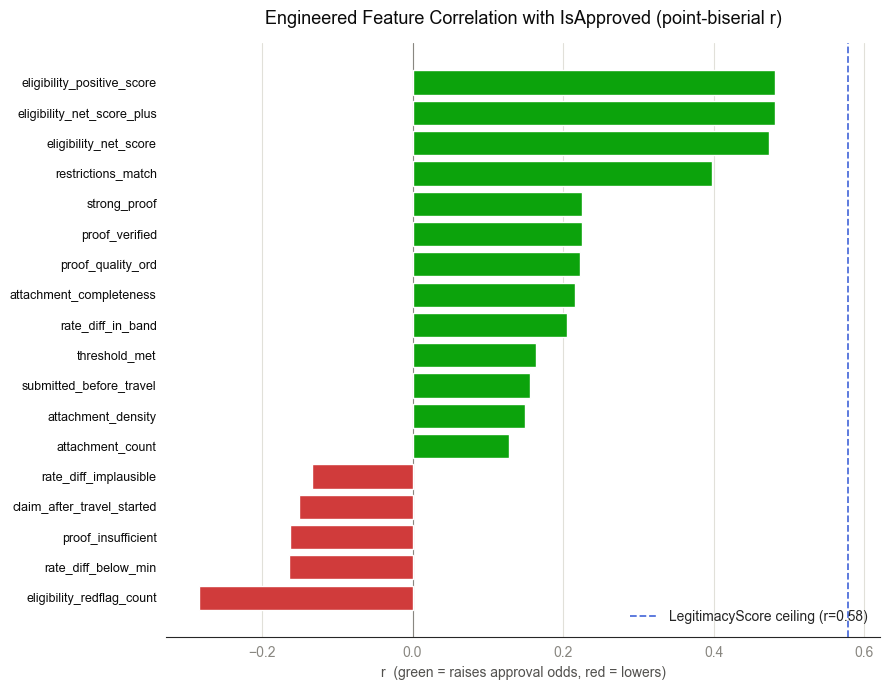

In [45]:
import matplotlib.pyplot as plt

top = corr_fe.head(18).sort_values('r')
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#0ca30c' if v > 0 else '#d03b3b' for v in top['r']]
ax.barh(top.index, top['r'], color=colors, zorder=3)
ax.axvline(0, color='#898781', linewidth=0.8)
ax.axvline(legit_ceiling, color='#4f6fdb', linestyle='--', linewidth=1.3,
           label=f'LegitimacyScore ceiling (r={legit_ceiling:.2f})')
ax.set_title('Engineered Feature Correlation with IsApproved (point-biserial r)',
             fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('r  (green = raises approval odds, red = lowers)', color='#52514e')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=9)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.show()


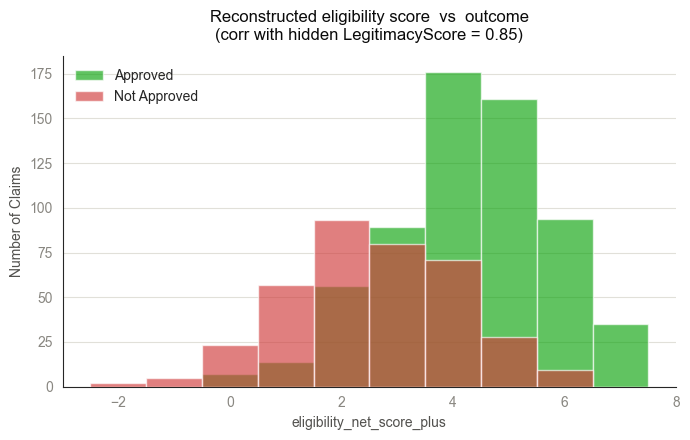

In [46]:
# How close did the reconstruction get to the hidden generator score?
recon = fe['eligibility_net_score_plus']
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, mask, color in [('Approved', y == 1, '#0ca30c'), ('Not Approved', y == 0, '#d03b3b')]:
    ax.hist(recon[mask], bins=np.arange(recon.min() - 0.5, recon.max() + 1.5),
            alpha=0.65, label=label, color=color, zorder=3)
ax.set_title("Reconstructed eligibility score  vs  outcome\n"
             f"(corr with hidden LegitimacyScore = {recon.corr(df['LegitimacyScore']):.2f})",
             fontsize=12, color='#0b0b0b', pad=12)
ax.set_xlabel('eligibility_net_score_plus', color='#52514e')
ax.set_ylabel('Number of Claims', color='#52514e')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### 16.7 Baseline models & feature importance

A quick sanity check that the engineered matrix is learnable: a scaled **Logistic Regression**
(interpretable baseline) and a **Random Forest**, on a stratified 70/30 split. Precision and recall
are reported separately — a false approval costs money, a false rejection costs customer trust.
`LegitimacyScore` is deliberately excluded so the score reflects only intake-time features.


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

logreg = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                       LogisticRegression(max_iter=2000, class_weight='balanced'))
rf = make_pipeline(SimpleImputer(strategy='median'),
                   RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                          random_state=42, class_weight='balanced_subsample',
                                          n_jobs=-1))

metrics = []
for name, model in [('Logistic Regression', logreg), ('Random Forest', rf)]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })
    print(f"{name}: confusion matrix [[TN, FP], [FN, TP]] = {confusion_matrix(y_test, pred).tolist()}")

pd.DataFrame(metrics).set_index('Model').round(3)


Logistic Regression: confusion matrix [[TN, FP], [FN, TP]] = [[78, 32], [43, 147]]


Random Forest: confusion matrix [[TN, FP], [FN, TP]] = [[71, 39], [22, 168]]


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.750,0.821,0.774,0.797,0.800
Random Forest,0.797,0.812,0.884,0.846,0.857


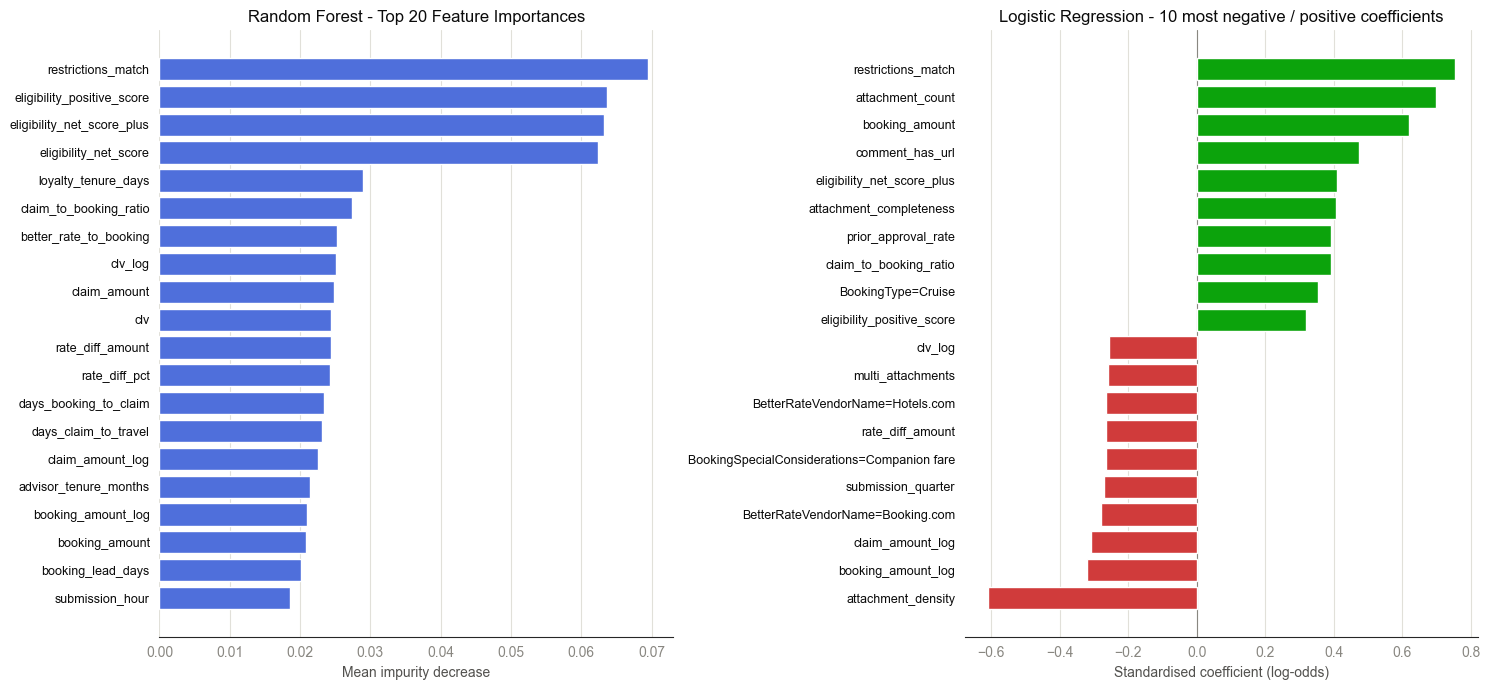

In [48]:
# Random Forest impurity importances + Logistic Regression standardised coefficients
rf_imp = pd.Series(rf.named_steps['randomforestclassifier'].feature_importances_,
                   index=X.columns).sort_values(ascending=False).head(20)
lr_coef = pd.Series(logreg.named_steps['logisticregression'].coef_[0],
                    index=X.columns).sort_values()
lr_top = pd.concat([lr_coef.head(10), lr_coef.tail(10)])

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(rf_imp.index[::-1], rf_imp.values[::-1], color='#4f6fdb', zorder=3)
axes[0].set_title('Random Forest - Top 20 Feature Importances', fontsize=12, color='#0b0b0b')
axes[0].set_xlabel('Mean impurity decrease', color='#52514e')

axes[1].barh(lr_top.index, lr_top.values,
             color=['#d03b3b' if v < 0 else '#0ca30c' for v in lr_top.values], zorder=3)
axes[1].axvline(0, color='#898781', linewidth=0.8)
axes[1].set_title('Logistic Regression - 10 most negative / positive coefficients',
                  fontsize=12, color='#0b0b0b')
axes[1].set_xlabel('Standardised coefficient (log-odds)', color='#52514e')

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', colors='#0b0b0b', labelsize=9)
    ax.tick_params(axis='x', colors='#898781')
    ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### Summary — engineered feature catalogue

| Group | Engineered features | Rationale |
| :-- | :-- | :-- |
| **Eligibility composites** | `eligibility_positive_score`, `eligibility_redflag_count`, `eligibility_net_score(_plus)` | Count of program-eligibility signals that fire for/against the claim. **Strongest engineered predictors (r ≈ 0.48)** — they recover most of the hidden `LegitimacyScore` signal (r = 0.58) from raw fields alone. |
| **Proof / documentation** | `proof_verified`, `proof_insufficient`, `proof_quality_ord`, `strong_proof`, `has_attachments`, `multi_attachments`, `attachment_density`, `proof_type_missing` | Documentation quality is the second-biggest driver after restrictions match. |
| **Restrictions & rate plausibility** | `restrictions_match`, `threshold_met`, `has_valid_url`, `blackout_or_excluded`, `rate_diff_in_band`, `rate_diff_below_min`, `rate_diff_implausible` | `restrictions_match` alone is r ≈ 0.40; the rate-difference band flags encode the "3–40 % plausible / >60 % implausible" rule. |
| **Submission timing** | `submitted_before_travel`, `submitted_after_travel`, `claim_after_travel_started` | Most BRG programs only allow "Before Travel" claims. |
| **Customer history** | `prior_approval_rate`, `prior_rejected_count`, `is_first_time_claimant`, `loyalty_tenure_days` | A customer's past approval behaviour is mildly predictive and operationally fair to use. |
| **Monetary / ratio** | `claim_amount_log`, `booking_amount_log`, `claim_to_booking_ratio`, `better_rate_to_booking`, `clv_log` | Normalised magnitudes; weak individually but useful to the tree model for interactions. |
| **Temporal** | `submission_month/quarter/dayofweek/hour`, `booking_lead_days`, `trip_duration_days` | Seasonality and booking-behaviour context. |
| **Text (customer-supplied)** | `has_customer_comment`, `comment_word_count`, `comment_has_url`, `comment_mentions_price` | Lightweight signal from `CustomerComments`; advisor notes excluded as leakage. |
| **One-hot categoricals** | `BookingType`, `BookingChannel`, `ClaimSubmissionChannel`, `ProofType`, `LoyaltyTier`, `AccountStatus`, `SeasonalityFlag`, `FareOrRatePlanFlexibility`, `BetterRateVendorName`, `BookingSpecialConsiderations` | Kept for completeness; Section 15 showed most add little beyond the quality signals. |

**Result:** a ~120-column matrix built only from intake-time fields lets a Random Forest reach
**ROC-AUC ≈ 0.85** without touching `LegitimacyScore`, and the picture matches Section 15 — approval
is driven by *claim-quality* signals (restrictions match, proof quality, rate plausibility,
submission timing), not by *customer* attributes (loyalty tier, account status) or submission
channel. The next step (data-prompt Section 8) is model selection / tuning with XGBoost or LightGBM
and SHAP for per-claim explanations.
